# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [ ]:

ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

descargado: taller1_datos.h5
descargado: verificacion.py
Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [ ]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [ ]:
import h5py
import numpy as np

archivo = "taller1_datos.h5"

with h5py.File(archivo, "r") as f:

    # 1. contenido del archivo
    print("=== CONTENIDO DEL ARCHIVO ===")

    def mostrar(nombre, objeto):
        print(nombre)

        # Mostrar atributos de grupos
        for atributo, valor in objeto.attrs.items():
            print(f"   atributo: {atributo} = {valor}")

    f.visititems(mostrar)

    # 2. Atributos generales del archivo
    print("\n=== ATRIBUTOS DEL ARCHIVO ===")
    for atributo, valor in f.attrs.items():
        print(f"{atributo}: {valor}")

    # 3. Contenido de estimulos
    print("\n=== GRUPO ESTIMULOS ===")
    estimulos = f["estimulos"]

    print("Contenido:", list(estimulos.keys()))

    print("\nAtributos de estimulos:")
    for atributo, valor in estimulos.attrs.items():
        print(f"{atributo}: {valor}")

    # 4. Número de ensayos
    n_ensayos = len(estimulos["condicion"])
    print("\nNúmero de ensayos:", n_ensayos)

    # 5. Condiciones distintas
    condiciones = estimulos["condicion"][:].astype(str)
    condiciones_unicas = np.unique(condiciones)

    print("Condiciones distintas:", condiciones_unicas)
    print("Número de condiciones:", len(condiciones_unicas))

    # 6. Duraciones
    pre = estimulos.attrs["duracion_pre_s"]
    dur_est = estimulos.attrs["duracion_estimulo_s"]
    post = estimulos.attrs["duracion_post_s"]

    duracion_ensayo = pre + dur_est + post

    print("\nDuración del ensayo:", duracion_ensayo, "s")
    print("Duración del estímulo:", dur_est, "s")

=== CONTENIDO DEL ARCHIVO ===
estimulos
   atributo: duracion_estimulo_s = 0.5
   atributo: duracion_post_s = 1.5
   atributo: duracion_pre_s = 1.0
   atributo: nota = tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.
estimulos/condicion
estimulos/tiempo_inicio_s
registro
registro/canal_0
verdad
   atributo: nota = Tiempos reales de espiga. Los usa verificacion.py.
verdad/artefactos_s
verdad/tiempos_s
verdad/unidad

=== ATRIBUTOS DEL ARCHIVO ===
descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s: 210.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 20000
n_canales: 1
unidades: microvoltios tras multiplicar por escala_uV_por_bit

=== GRUPO ESTIMULOS ===
Contenido: ['condicion', 'tiempo_inicio_s']

Atributos de estimulos:
duracion_estimulo_s: 0.5
duracion_post_s: 1.5
duracion_pre_s: 1.0
nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s d

**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: 3
- duración del ensayo: 3 s · pre-estímulo: 1 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

NAVY = "navy"

archivo = "taller1_datos.h5"

with h5py.File(archivo, "r") as f:

    fs = f.attrs["frecuencia_muestreo_hz"]
    escala = f.attrs["escala_uV_por_bit"]

    # Señal almacenada en bits
    senal_bits = f["registro"]["canal_0"][:]

    # Convertir a microvoltios
    senal = senal_bits * escala

# Vector de tiempo
t = np.arange(len(senal)) / fs

print("Frecuencia de muestreo:", fs, "Hz")
print("Número de muestras:", len(senal))
print("Duración:", t[-1], "s")

def ver(x, titulo, t0=0.0, t1=0.5, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""

    m = (t >= t0) & (t < t1)

    plt.figure(figsize=(12, 4))

    plt.plot(t[m], x[m], color=color, lw=0.9)

    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (µV)")

Frecuencia de muestreo: 20000 Hz
Número de muestras: 4200000
Duración: 209.99995 s


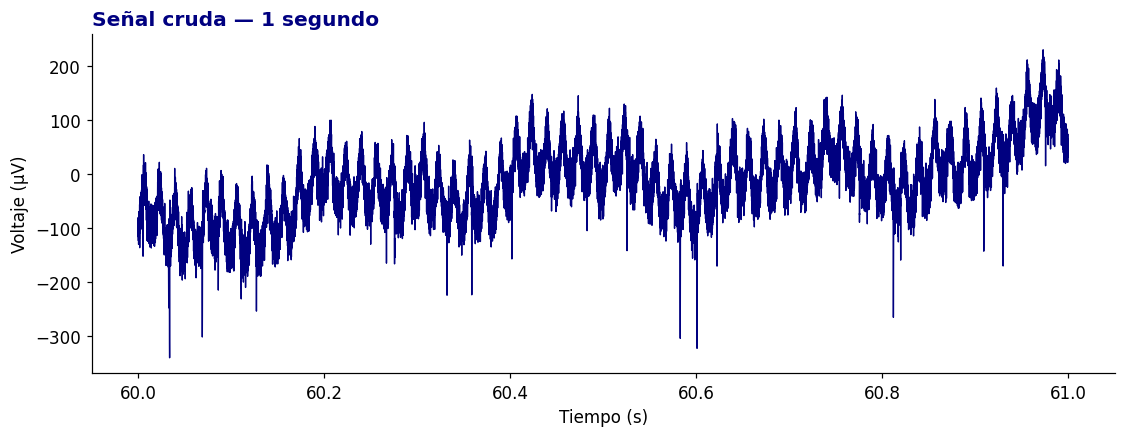

In [ ]:
ver(senal, "Señal cruda — 1 segundo", t0=60, t1=61)

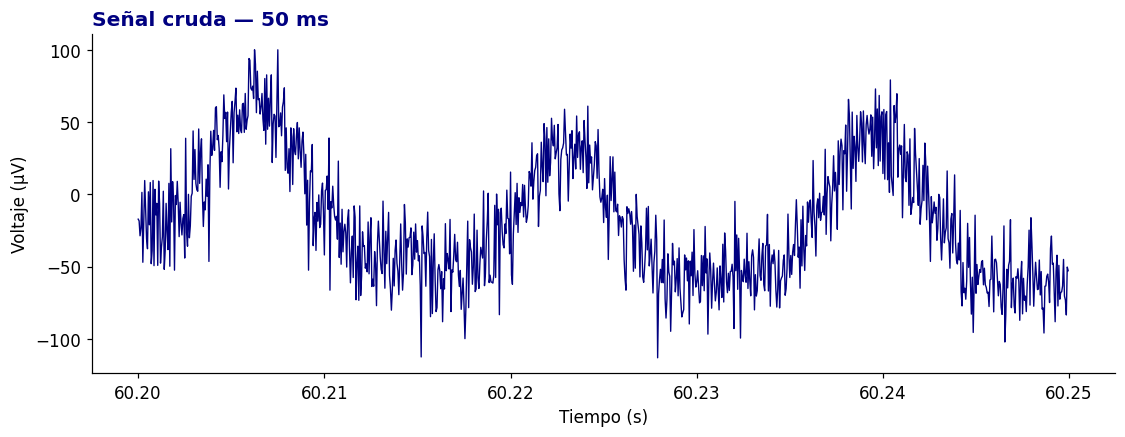

In [ ]:
ver(senal, "Señal cruda — 50 ms", t0=60.20, t1=60.25)

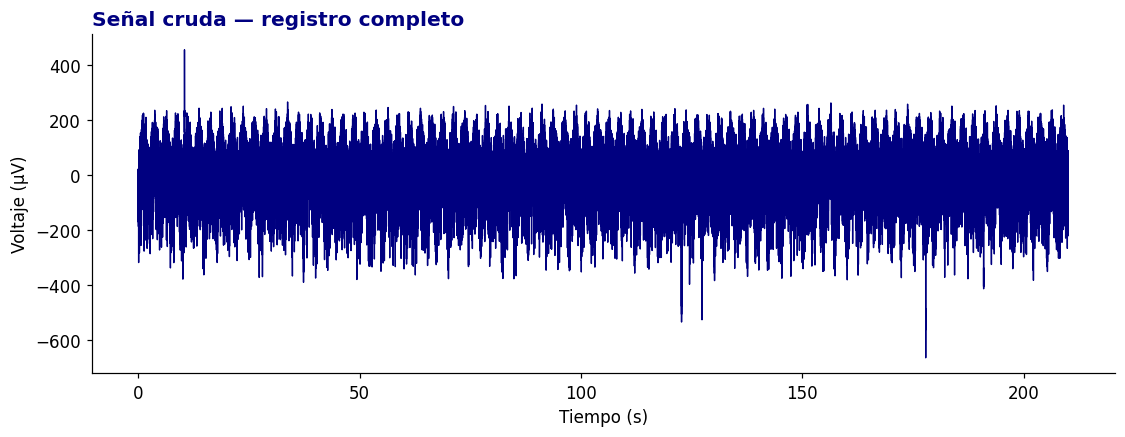

In [ ]:
ver(senal, "Señal cruda — registro completo", t0=0, t1=210)

**Los tres problemas que encontramos:**

1.En la segunda grafica se pueden ver picos debido a interferencias por otros equipos electronicos o movimientos repentinos del sujeto.
2. la grafica de la señal cruda tiene mucho ruido, lo cual no permite distinguir potenciales de accion del ruido.
3. Se ve una deriva lenta, que puede ser producida por variancias de las concentraciones de iones al rededor de la sonda, o si la respiracion del sujeto mueve el electrodo.

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3?

la tercera grafica, del registro completo, nos impide encontrar los disparos a ojo ya que es mucha informacion comprimida. por ende no se puede diferenciar que es ruido y que es un disparo de la neurona. Tambien se debe mencionar que se encuentra mucho ruido, lo cual lo hace la distincion de picos mas dificil.

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt: Estoy trabajando en Python con una señal de voltaje almacenada en un array x y conozco su frecuencia de muestreo fs. Necesito una función llamada espectro(x, fs, etiqueta, fmax=500) que calcule el espectro de potencia usando scipy.signal.welch con nperseg=8192.
La función debe devolver dos arrays: f, con las frecuencias en Hz, y P, con la potencia correspondiente a cada frecuencia. Además, debe hacer una gráfica mostrando solo las frecuencias hasta fmax, usar plt.semilogy para que el eje Y quede en escala logarítmica, poner etiqueta como título y rotular ambos ejes con sus unidades. No uses FFT directamente ni cambies el valor de nperseg.


>

Pico dominante entre 40 y 200 Hz: 61.0 Hz


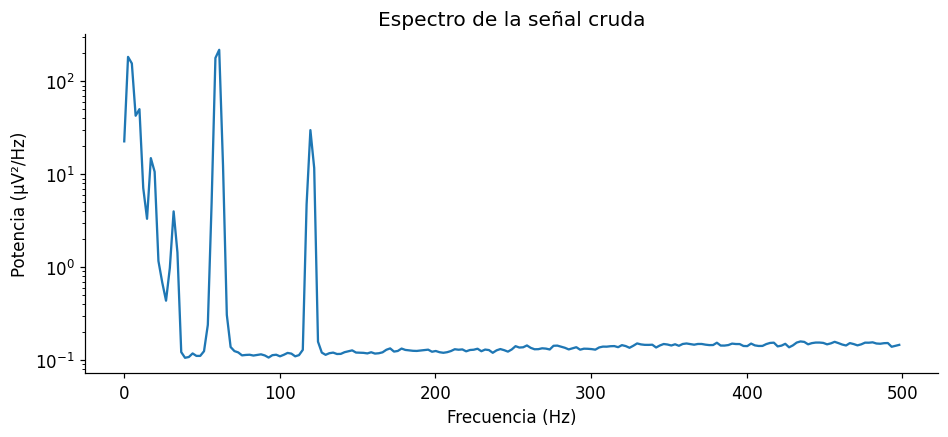

In [ ]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def espectro(x, fs, etiqueta, fmax=500):
    """
    Calcula y grafica el espectro de potencia de una señal usando Welch.
    """

    # Calcular espectro de potencia
    f, P = welch(x, fs=fs, nperseg=8192)

    # Mostrar solo frecuencias hasta fmax
    m = f <= fmax

    plt.figure(figsize=(10, 4))
    plt.semilogy(f[m], P[m])
    plt.title(etiqueta)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (µV²/Hz)")

    return f, P


# Aplicar la función a la señal cruda
f, P = espectro(senal, fs, "Espectro de la señal cruda")


# Frecuencia con más potencia entre 40 y 200 Hz
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])

print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")


In [ ]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_
- Con ese nperseg y fs, la resolucion es de ~2.4 Hz, debido a que el espectro solo puede representar frecuencias separadas por ese intervalo especifico. Por ende, el máximo de la red eléctrica no aparece exactamente en 60 Hz, si no aparece en el bin más cercano.

- Dentro de un segmento cabe alrededor de 0.16 ciclos, ya que cada segmento (8192/20000) dura 0.4096 s, mientras que una deriva de 0.4 Hz tiene un período de 2.5 s. Cuando se aumenta nperseg a 200000, cada segmento dura 10 s y la resolución sube a 0.1 Hz. De esta manera el componente mas cercano a 0.4 Hz es mas facil de apreciar. A cambio, se utilizaron menos segmentos y la estimación del espectro se vuelve más ruidosa.

- La escala logarítmica se usa en el eje y ya que permite observar componentes con potencias *muy* diferentes simultaneamente.

Resolución: 2.4414 Hz
Pico encontrado: 61.0352 Hz
Diferencia con 60 Hz: 1.0352 Hz

Segundo pico: 119.6289 Hz

Duración de un segmento de Welch: 0.4096 s
Período de la deriva de 0.4 Hz: 2.50 s
Ciclos de la deriva que caben: 0.164

Nueva resolución: 0.10 Hz
Nueva duración del segmento: 10.0 s
Pico dominante por debajo de 1 Hz: 0.4 Hz


Text(0.5, 1.0, 'Espectro por debajo de 1 Hz — nperseg = 200000')

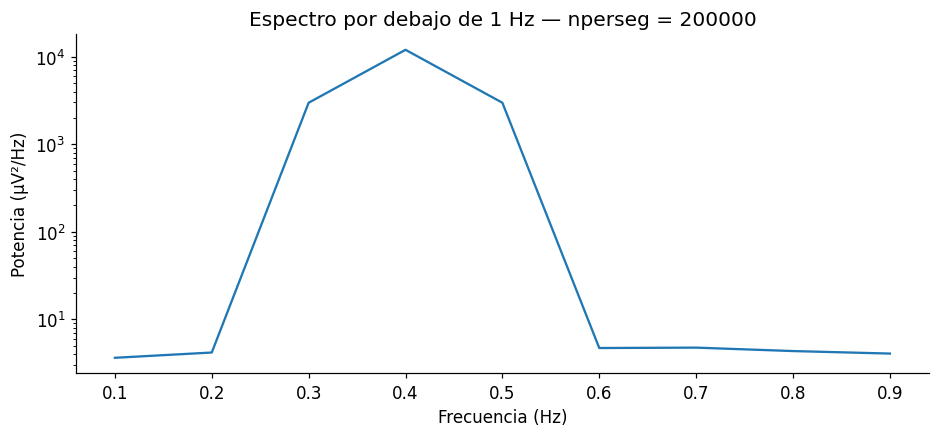

In [ ]:
# 1. Resolución del espectro
resolucion = f[1] - f[0]
print(f"Resolución: {resolucion:.4f} Hz")
print(f"Pico encontrado: {pico:.4f} Hz")
print(f"Diferencia con 60 Hz: {abs(pico - 60):.4f} Hz")


# 2. Buscar el segundo pico cerca de 120 Hz
m120 = (f > 100) & (f < 140)
pico120 = float(f[m120][np.argmax(P[m120])])
print(f"\nSegundo pico: {pico120:.4f} Hz")


# 3. Comparar duración del segmento con la deriva
nperseg = 8192
dur_segmento = nperseg / fs

periodo_deriva = 1 / 0.4
ciclos = dur_segmento / periodo_deriva

print(f"\nDuración de un segmento de Welch: {dur_segmento:.4f} s")
print(f"Período de la deriva de 0.4 Hz: {periodo_deriva:.2f} s")
print(f"Ciclos de la deriva que caben: {ciclos:.3f}")


# 4. Repetir Welch con segmentos más largos
from scipy.signal import welch

f_largo, P_largo = welch(senal, fs=fs, nperseg=200000)

print(f"\nNueva resolución: {f_largo[1] - f_largo[0]:.2f} Hz")
print(f"Nueva duración del segmento: {200000/fs:.1f} s")

m_bajo = (f_largo > 0) & (f_largo < 1)
pico_bajo = float(f_largo[m_bajo][np.argmax(P_largo[m_bajo])])

print(f"Pico dominante por debajo de 1 Hz: {pico_bajo:.1f} Hz")

plt.figure(figsize=(10,4))
plt.semilogy(f_largo[m_bajo], P_largo[m_bajo])
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (µV²/Hz)")
plt.title("Espectro por debajo de 1 Hz — nperseg = 200000")

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt: Estoy trabajando en Python con una señal de voltaje x y conozco su frecuencia de muestreo fs. Necesito una sola función llamada filtrar(x, fs, baja=None, alta=None, orden=3) que use un filtro Butterworth.
La función debe:
aplicar un filtro pasa-bajos si solo se especifica alta;
aplicar un filtro pasa-altos si solo se especifica baja;
aplicar un filtro pasa-banda si se especifican baja y alta;
normalizar las frecuencias de corte usando la frecuencia de Nyquist (fs/2);
aplicar el filtro con fase cero usando filtfilt o sosfiltfilt;
devolver una señal filtrada del mismo tamaño que x.
Usa scipy.signal y no introduzcas retrasos temporales en la señal.
>

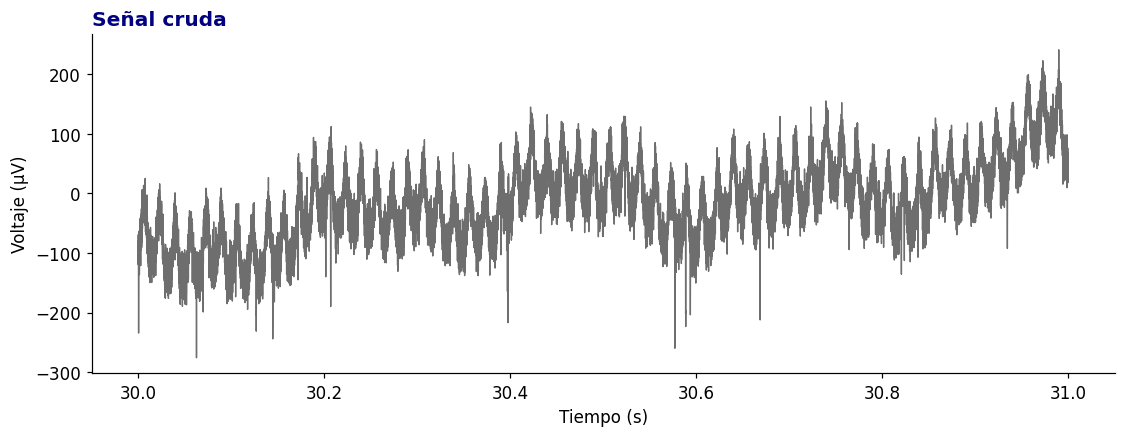

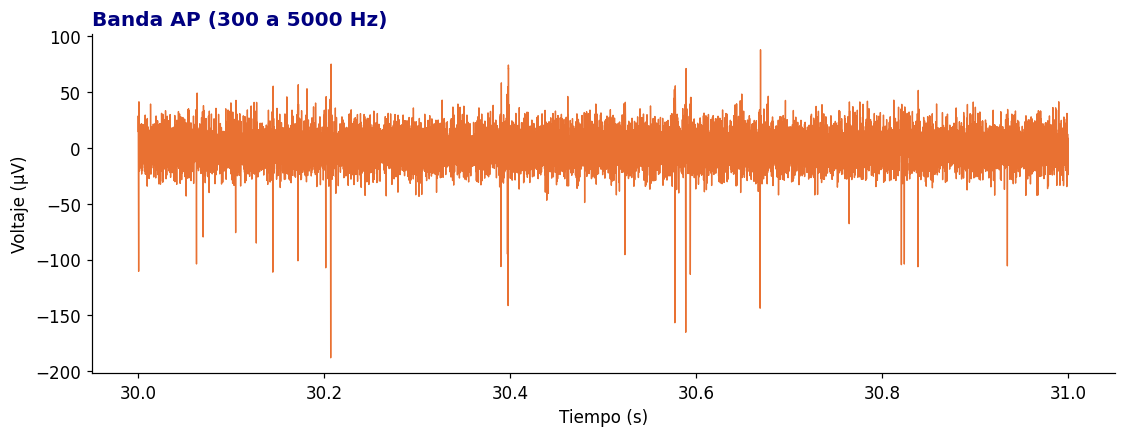

In [ ]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.

#AP = ____       # pasa-banda de 300 a 5000 Hz sobre la señal cruda

#plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
#plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

from scipy.signal import butter, sosfiltfilt

def filtrar(x, fs, baja=None, alta=None, orden=3):

    nyquist = fs / 2

    if baja is None and alta is None:
        return x.copy()

    elif baja is None:
        # Pasa-bajos
        corte = alta / nyquist
        sos = butter(orden, corte, btype="lowpass", output="sos")

    elif alta is None:
        # Pasa-altos
        corte = baja / nyquist
        sos = butter(orden, corte, btype="highpass", output="sos")

    else:
        # Pasa-banda
        cortes = [baja / nyquist, alta / nyquist]
        sos = butter(orden, cortes, btype="bandpass", output="sos")

    return sosfiltfilt(sos, x)


# Banda de potenciales de acción: 300 a 5000 Hz
AP = filtrar(cruda, fs, baja=300, alta=5000)


ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_

1. El ruido y los potenciales de accion no estan en las mismas frcuencias. Debido a que el paso de banda solo conserva de 300-5000 Hz, y el ruido esta a 60hz, por ende el paso de banda esta haciendo el trabajo de notch.

2.La deriva tiene frecuencias bajas, por ende fueron filtradas con el corte de 300-5000 Hz. algunos de los artefactos grandes se reducioeron, aunque no todos, ya que se pueden observar algunos picos.

3. notch haria falta en caso de que las frequencias que se desean observar queden por debajo de 300Hz y sean cercanas a 60Hz.

### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

## respuesta
el codigo si sirve. La parte importante es que iirnotch recibe explícitamente fs=fs, así que las frecuencias f0=60 y f0=120 se interpretan correctamente en Hz. También usa filtfilt, por lo que el filtro se aplica con fase cero y no desplaza los eventos en el tiempo

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

In [ ]:
import numpy as np
from scipy.signal import iirnotch, filtfilt

def notch(x, f0, fs, Q=30):
    """
    Elimina una frecuencia específica f0 de una señal.

    x  : señal de voltaje (µV)
    f0 : frecuencia que se quiere eliminar (Hz)
    fs : frecuencia de muestreo (Hz)
    Q  : factor de calidad del notch
    """

    # Diseñar el filtro notch centrado en f0
    b, a = iirnotch(f0, Q, fs=fs)

    # Aplicarlo hacia adelante y hacia atrás para evitar desfase
    x_filtrada = filtfilt(b, a, x)

    return x_filtrada

In [ ]:
Q = 30
f0 = 60

In [ ]:
# Quitar ruido de red de 60 Hz
sin60 = notch(cruda, 60, fs, Q=30)

# Quitar su armónico de 120 Hz
sin60_120 = notch(sin60, 120, fs, Q=30)

# Obtener banda LFP: frecuencias menores de 300 Hz
LFP = filtrar(sin60_120, fs, alta=300)

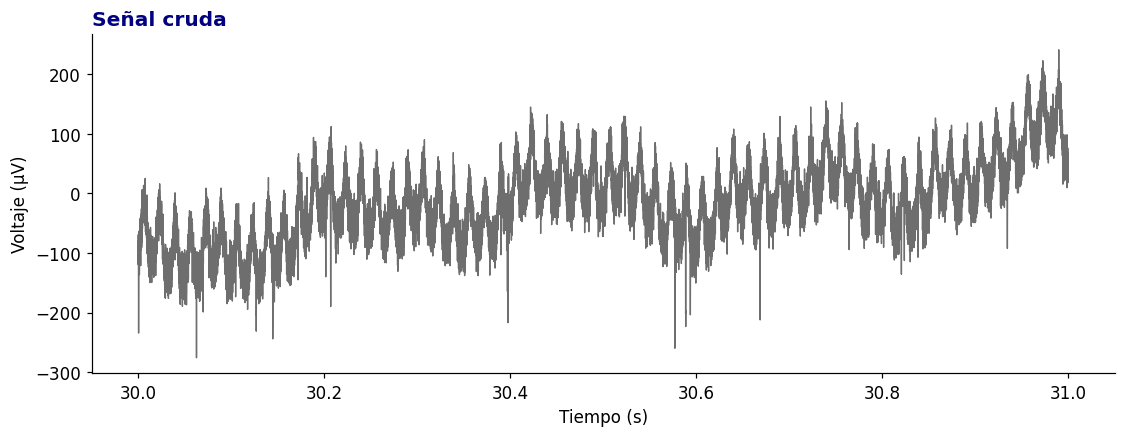

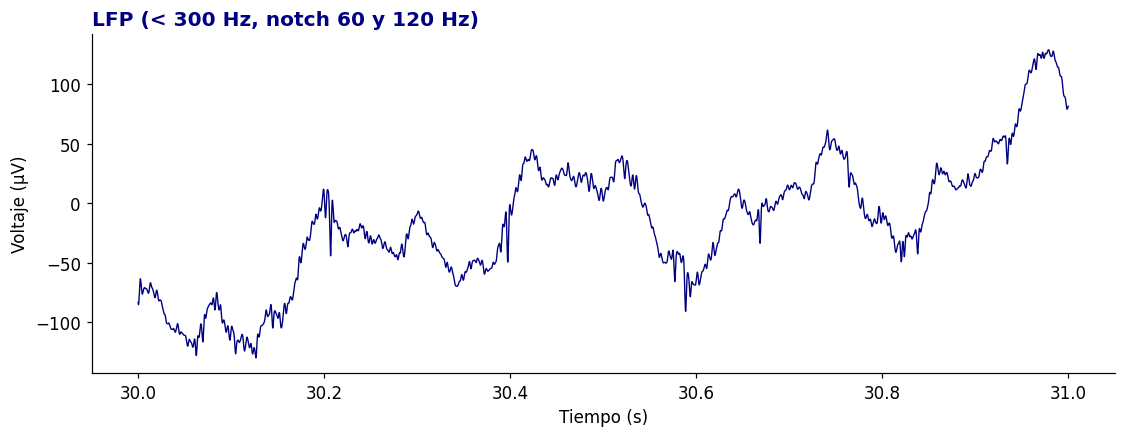

In [ ]:
ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)

ver(LFP, "LFP (< 300 Hz, notch 60 y 120 Hz)",
    t0=30.0, t1=31.0, color=NAVY)

<Figure size 1320x374 with 0 Axes>

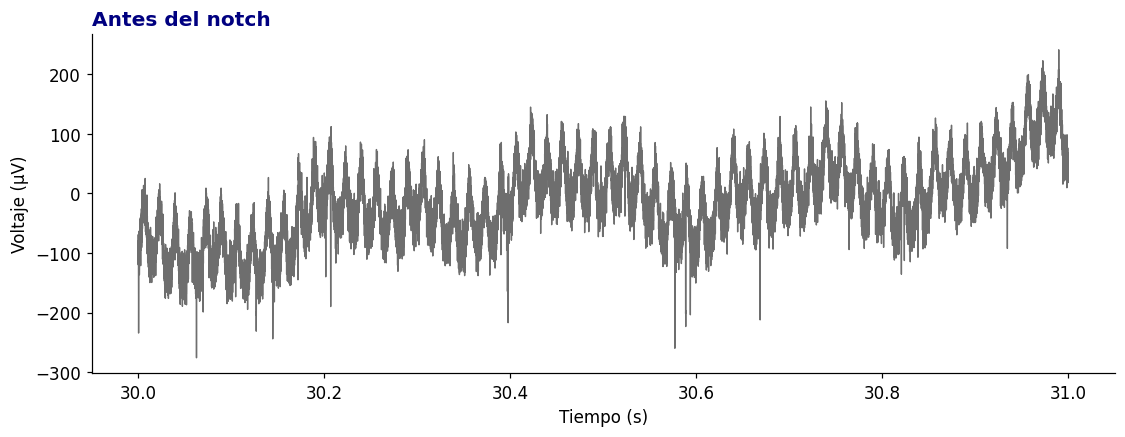

<Figure size 1320x374 with 0 Axes>

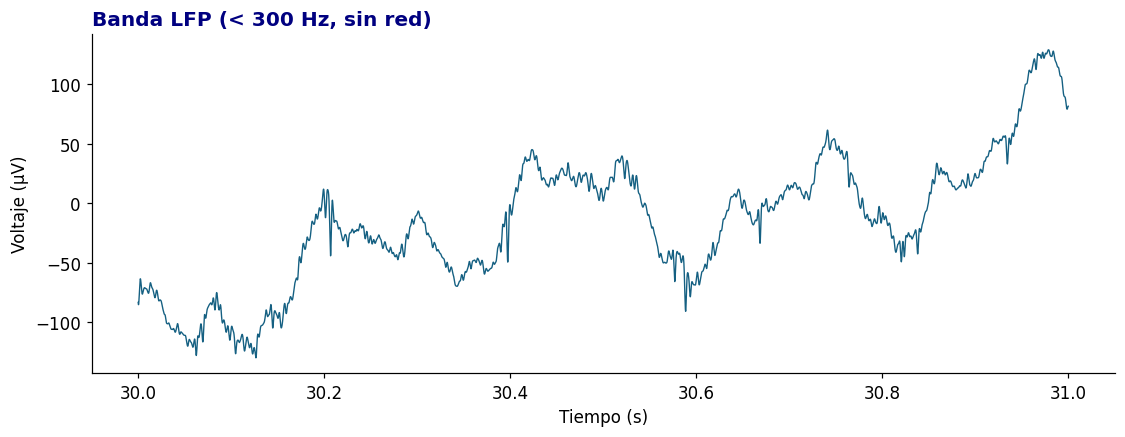

In [ ]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.

#sin_red = ____            # la señal cruda sin ruido de red
#LFP     = ____            # pasa-bajos de 300 Hz sobre sin_red

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin60_120,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin60_120, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin60_120, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_

- Al aplicar un notch en 9 Hz, se elimina una parte de la señal biológica ya que 9 Hz esta dentro de la banda que se busca conservar. Esto muestra que notch no logra distinguir entre "ruido" y "señal biológica", solo se elimina la frecuencia indicada.

- El filtro se vuelve mucho más ancho cuando notch se baja de 60 Hz a Q = 2. Por ende no elimina solo una región pequeña alrededor de 60 Hz, sino también frecuencias cercanas que podrían contener "señal biológica". Por ende, Q controla el ancho de banda de notch.

- En el corte de Hz (inferior) aún pasan unas componentes de baja frequencia que no son deseados en la banda AP. Ya con el corte de 800 Hz, se cortan elementos de estas menores frequencias pero que si hacen parte del potencial de accion. Por ende, 300 Hz, logra filtrar ruido de mas bajas frequencias sin deformar los picos de lso potenciales de accion.

- Concluimos que el diagnostico se debe hacer antes del filtrado ya que uno debe identificar cuales son las frqeucnias de ruido y cuales son las de señal biologica. Si no se identifican de primeras, se podria eleminar la señal que se esta buscando.



---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [ ]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):

    """Devuelve los índices de las muestras donde hay un potencial de acción."""

    # Estimar el ruido con MAD
    sigma = np.median(np.abs(x)) / 0.6745

    # Umbral negativo
    umbral = -k * sigma

    # Muestras que están por debajo del umbral
    debajo = np.where(x < umbral)[0]

    # Si no hay cruces
    if len(debajo) == 0:
        return np.array([], dtype=int)

    # Separar las muestras contiguas en eventos
    cortes = np.where(np.diff(debajo) > 1)[0] + 1
    grupos = np.split(debajo, cortes)

    # Quedarse con el punto más negativo de cada evento
    candidatos = []

    for grupo in grupos:
        minimo = grupo[np.argmin(x[grupo])]
        candidatos.append(minimo)

    # Período muerto en número de muestras
    muerto_muestras = int(muerto_ms * fs / 1000)

    # Aplicar período muerto
    indices = []

    for i in candidatos:
        if len(indices) == 0 or i - indices[-1] >= muerto_muestras:
            indices.append(i)

    return np.array(indices, dtype=int)


indices = detectar_spikes(AP, fs)

tiempos = indices / fs

sigma  = np.median(np.abs(AP)) / 0.6745
umbral = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")

print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5461 disparos en 210 s (26.0 por segundo)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

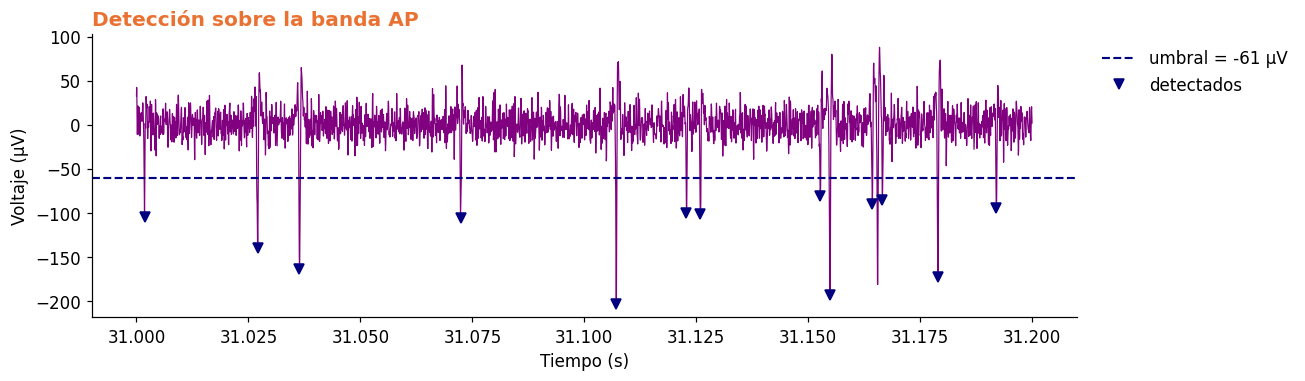

In [ ]:
t0, t1 = 31.0, 31.2

m = (t >= t0) & (t < t1)

d = indices[(tiempos >= t0) & (tiempos < t1)]

plt.figure(figsize=(12, 3.6))

plt.plot(t[m], AP[m], color="Purple", lw=0.8)

plt.axhline(
    umbral,
    color=NAVY,
    ls="--",
    lw=1.4,
    label=f"umbral = {umbral:.0f} µV"
)

plt.plot(
    t[d],
    AP[d],
    "v",
    color=NAVY,
    ms=7,
    ls="none",
    label="detectados"
)

plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (µV)")

plt.title(
    "Detección sobre la banda AP",
    color=ORANGE,
    fontweight="bold",
    loc="left"
)

plt.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt: Tengo dos arreglos ordenados con tiempos de potenciales de acción en segundos: uno contiene las detecciones de mi algoritmo (detectados_s) y el otro los eventos reales (reales_s). Quiero crear una función emparejar(detectados_s, reales_s, tol_ms=1.0) que compare ambos y retorne tres valores: verdaderos positivos (VP), falsos positivos (FP) y falsos negativos (FN).
Dos eventos deben considerarse una coincidencia si la diferencia entre sus tiempos es menor o igual a la tolerancia indicada en milisegundos, por lo que primero hay que convertir tol_ms a segundos. Además, cada evento real solo puede asociarse con una detección y cada detección solo puede utilizarse una vez. Como los tiempos ya están ordenados, recorre ambos arreglos de forma secuencial y avanza los índices según haya una coincidencia, una detección sin correspondencia o un evento real que no fue detectado. Al final, cuenta también los elementos que hayan quedado sin emparejar.

>

In [ ]:
def emparejar(detectados_s, reales_s, tol_ms=1.0):


    tol = tol_ms / 1000

    i = 0
    j = 0

    VP = 0
    FP = 0
    FN = 0

    while i < len(detectados_s) and j < len(reales_s):

        diferencia = detectados_s[i] - reales_s[j]

        if abs(diferencia) <= tol:
            VP += 1
            i += 1
            j += 1

        elif detectados_s[i] < reales_s[j]:
            FP += 1
            i += 1

        else:
            FN += 1
            j += 1

    FP += len(detectados_s) - i
    FN += len(reales_s) - j

    return VP, FP, FN

In [ ]:
import verificacion as v

v.usar(ARCHIVO)

reales = v.spikes_de_referencia()

VP, FP, FN = emparejar(tiempos, reales)

print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5457   FP = 4   FN = 166
precisión     = 0.999
exhaustividad = 0.970


In [ ]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5461 spikes
  En realidad hay    5623
  Aciertos           5457   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.0%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

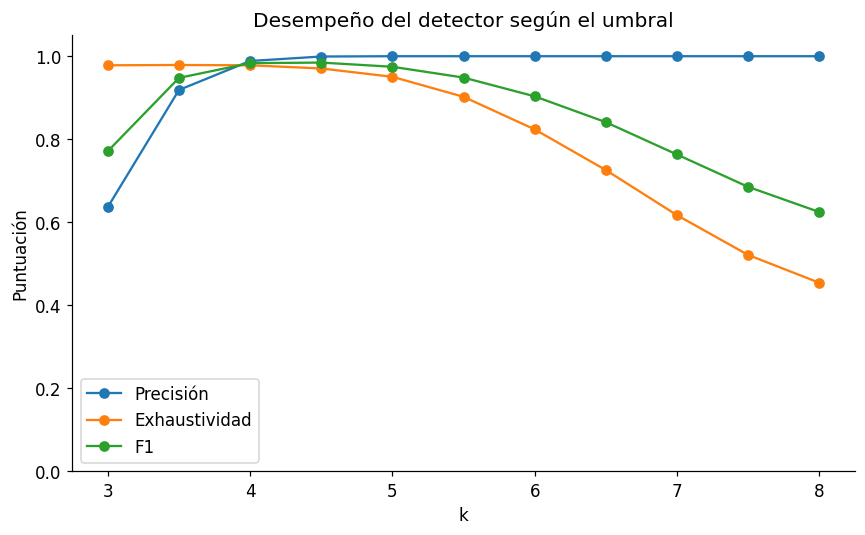

In [ ]:
ks = np.arange(3, 8.1, 0.5)

precisiones = []
exhaustividades = []
f1s = []

for k in ks:

    # Detectar spikes usando este valor de k
    indices_k = detectar_spikes(AP, fs, k=k)

    # Pasar los índices a segundos
    tiempos_k = indices_k / fs

    # Comparar con los spikes reales
    VP, FP, FN = emparejar(tiempos_k, reales)

    # Calcular precisión y exhaustividad
    precision = VP / (VP + FP)
    exhaustividad = VP / (VP + FN)

    # Calcular F1
    F1 = 2 * precision * exhaustividad / (precision + exhaustividad)

    precisiones.append(precision)
    exhaustividades.append(exhaustividad)
    f1s.append(F1)


# Graficar las tres curvas
plt.figure(figsize=(8, 5))

plt.plot(ks, precisiones, "o-", label="Precisión")
plt.plot(ks, exhaustividades, "o-", label="Exhaustividad")
plt.plot(ks, f1s, "o-", label="F1")

plt.xlabel("k")
plt.ylabel("Puntuación")
plt.title("Desempeño del detector según el umbral")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

In [ ]:
mejor = np.argmax(f1s)

print(f"k con mayor F1: {ks[mejor]:.1f}")
print(f"Precisión: {precisiones[mejor]:.3f}")
print(f"Exhaustividad: {exhaustividades[mejor]:.3f}")
print(f"F1: {f1s[mejor]:.3f}")

k con mayor F1: 4.5
Precisión: 0.999
Exhaustividad: 0.970
F1: 0.985


### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [ ]:
# Intervalos entre spikes reales consecutivos
intervalos = np.diff(reales)

# Pasar el período muerto a segundos
muerto_s = 1.5 / 1000

# Contar pares separados por menos de 1.5 ms
cortos = intervalos < muerto_s

print("Pares de spikes separados por menos de 1.5 ms:", np.sum(cortos))

# Ver algunos de esos intervalos
for i in np.where(cortos)[0][:10]:
    print(f"{reales[i]:.6f} s  ->  {reales[i+1]:.6f} s   "
          f"({intervalos[i]*1000:.3f} ms)")

Pares de spikes separados por menos de 1.5 ms: 122
2.012707 s  ->  2.013973 s   (1.266 ms)
8.511817 s  ->  8.513059 s   (1.242 ms)
8.964106 s  ->  8.964821 s   (0.715 ms)
9.498622 s  ->  9.499298 s   (0.676 ms)
12.224804 s  ->  12.225298 s   (0.494 ms)
13.678433 s  ->  13.679708 s   (1.275 ms)
16.314103 s  ->  16.314240 s   (0.137 ms)
16.497213 s  ->  16.497841 s   (0.628 ms)
19.944341 s  ->  19.945614 s   (1.274 ms)
21.588796 s  ->  21.588973 s   (0.177 ms)


In [ ]:
# Detector con período muerto más corto
indices_04 = detectar_spikes(AP, fs, k=4.5, muerto_ms=0.4)

# Pasar índices a segundos
tiempos_04 = indices_04 / fs

# Comparar con la verdad
VP_04, FP_04, FN_04 = emparejar(tiempos_04, reales)

precision_04 = VP_04 / (VP_04 + FP_04)
exhaustividad_04 = VP_04 / (VP_04 + FN_04)

print(f"VP = {VP_04}   FP = {FP_04}   FN = {FN_04}")
print(f"precisión     = {precision_04:.3f}")
print(f"exhaustividad = {exhaustividad_04:.3f}")

VP = 5519   FP = 7   FN = 104
precisión     = 0.999
exhaustividad = 0.982


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

los resultados sugieren que los spikes pequeños que no cruzan el umbral explican la mayoría. Al bajar el período muerto de 1,5 a 0,4 ms, los FN disminuyeron de 166 a 104, es decir, recuperamos 62 disparos. Sin embargo, todavía quedaron 104 FN, por lo que el período muerto no era la única causa. Nos quedaríamos con 0,4 ms, porque en el registro hay tres neuronas y dos neuronas diferentes sí pueden disparar con menos de 1,5 ms de diferencia. Además, la exhaustividad aumentó de aproximadamente 0,970 a 0,982, mientras que la precisión se mantuvo prácticamente igual en 0,999. El costo fue un aumento pequeño de falsos positivos.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs


---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona? no

In [ ]:
# Su código aquí.
# Al final debe quedar definida la matriz de formas:

#formas = ____        # matriz n_disparos x n_muestras

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.

# Tamaño de la ventana en muestras
pre = int(0.7e-3 * fs)      # 0.7 ms antes
post = int(1.3e-3 * fs)     # 1.3 ms después

formas = []
indices_validos = []

for idx in indices:

    inicio = idx - pre
    fin = idx + post

    # Solo guardar spikes cuya ventana completa cabe en AP
    if inicio >= 0 and fin <= len(AP):
        formas.append(AP[inicio:fin])
        indices_validos.append(idx)

# Convertir a arrays
formas = np.array(formas)
indices = np.array(indices_validos, dtype=int)

# Volver a calcular los tiempos para que correspondan a los mismos spikes
tiempos = indices / fs

print("Dimensiones de formas:", formas.shape)
print("Número de índices:", len(indices))
print("Número de tiempos:", len(tiempos))

Dimensiones de formas: (5461, 40)
Número de índices: 5461
Número de tiempos: 5461


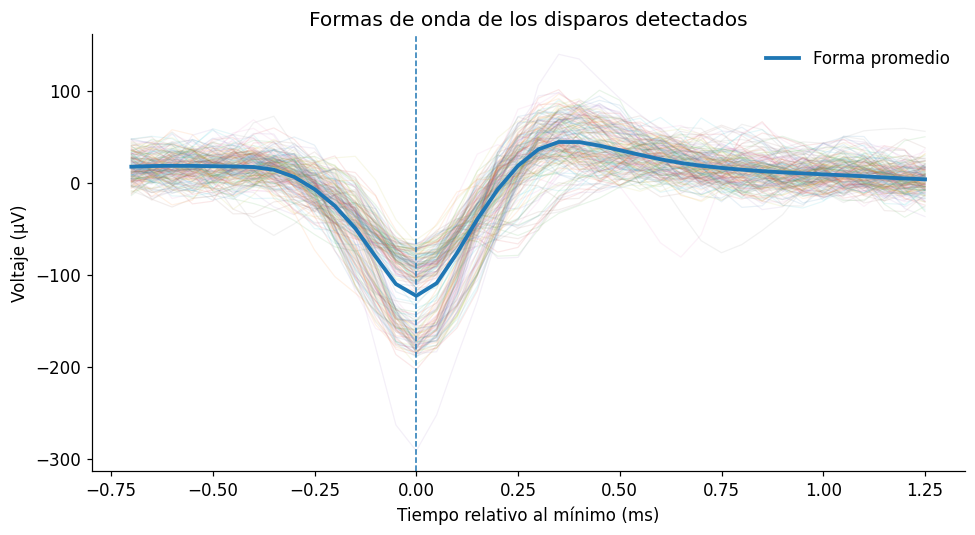

In [ ]:
# Tiempo de cada muestra respecto al mínimo del spike, en milisegundos
eje_ms = (np.arange(formas.shape[1]) - pre) * (1000 / fs)

# Elegir 200 formas repartidas a lo largo de todo el registro
n_mostrar = min(200, len(formas))
seleccion = np.linspace(0, len(formas) - 1, n_mostrar, dtype=int)

# Forma promedio de todos los disparos
forma_media = formas.mean(axis=0)

plt.figure(figsize=(9, 5))

# 200 formas individuales superpuestas
for i in seleccion:
    plt.plot(eje_ms, formas[i], alpha=0.1, lw=0.8)

# Promedio encima de las formas individuales
plt.plot(
    eje_ms,
    forma_media,
    lw=2.5,
    label="Forma promedio"
)

# El mínimo detectado está en t = 0 ms
plt.axvline(0, ls="--", lw=1)

plt.xlabel("Tiempo relativo al mínimo (ms)")
plt.ylabel("Voltaje (µV)")
plt.title("Formas de onda de los disparos detectados")

plt.legend(frameon=False)
plt.tight_layout()

In [ ]:
t_forma = np.arange(-pre, post) / fs * 1000
# esto es para la grafica de las 200 formas

In [ ]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

# respuesta

Amplitud: la calculamos a partir del valor mínimo de cada forma de onda, porque en este registro los spikes tienen una deflexión principalmente negativa. Podemos expresar la amplitud como la magnitud de ese mínimo, de forma que un spike más profundo tenga una amplitud mayor. Su unidad es µV.
Pendiente de bajada: mide qué tan rápido disminuye el voltaje antes de llegar al mínimo del spike. Para calcularla, se observa la parte de la forma de onda anterior al mínimo, se calcula el cambio de voltaje entre muestras consecutivas y se divide por el tiempo entre esas muestras. Nos podemos quedar con la pendiente más negativa, que representa la caída más rápida. Su unidad es µV/ms.
- Para convertir muestras a tiempo usamos la frecuencia de muestreo. Como fs = 20000 Hz, cada muestra representa 1/fs segundos, es decir, 0.05 ms. En general, una diferencia de n muestras se convierte a milisegundos con n/fs * 1000.

- -  Para utilizar estas características en K-means debemos construir una matriz donde cada fila represente un spike y las columnas correspondan a las características. En nuestro caso tendría dos columnas: la primera con la amplitud y la segunda con la pendiente de bajada. Si tenemos 5461 spikes, por ejemplo, la matriz tendría dimensiones 5461 × 2.

- - - Sí es conveniente escalar las características antes de aplicar K-means. La amplitud está en µV y la pendiente en µV/ms, y además pueden tener rangos numéricos muy diferentes. Como K-means forma los grupos utilizando distancias entre los puntos, una variable con valores mucho mayores podría dominar el agrupamiento. Estandarizarlas permite que ambas características tengan un peso comparable.
- - - Usamos K = 3 porque en este ejercicio ya sabemos que el registro contiene actividad de tres neuronas.


In [ ]:
# Su código aquí: características, gráfico de dispersión y agrupación.

#etiquetas = ____     # un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)""
# Tiempo entre dos muestras consecutivas, en ms
dt_ms = 1000 / fs

amplitudes = []
pendientes = []

for forma in formas:

    # 1. Amplitud: profundidad del mínimo, expresada como valor positivo
    amplitud = -np.min(forma)

    # 2. Parte de la forma que ocurre antes y hasta el mínimo
    bajada = forma[:pre + 1]

    # Pendiente entre muestras consecutivas, en µV/ms
    cambios = np.diff(bajada) / dt_ms

    # La pendiente más negativa representa la caída más rápida
    pendiente = np.min(cambios)

    amplitudes.append(amplitud)
    pendientes.append(pendiente)

amplitudes = np.array(amplitudes)
pendientes = np.array(pendientes)

print("Número de amplitudes:", len(amplitudes))
print("Número de pendientes:", len(pendientes))

print(f"Amplitud: {amplitudes.min():.1f} a {amplitudes.max():.1f} µV")
print(f"Pendiente: {pendientes.min():.1f} a {pendientes.max():.1f} µV/ms")

Número de amplitudes: 5461
Número de pendientes: 5461
Amplitud: 60.9 a 334.4 µV
Pendiente: -1849.6 a -199.1 µV/ms


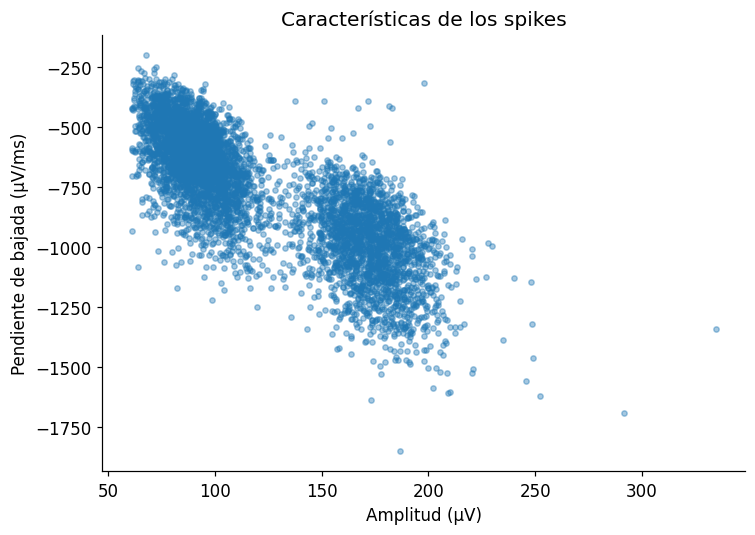

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(amplitudes, pendientes, s=12, alpha=0.4)

plt.xlabel("Amplitud (µV)")
plt.ylabel("Pendiente de bajada (µV/ms)")
plt.title("Características de los spikes")

plt.tight_layout()

Dimensiones: (5461, 2)
Unidad 0: 1968 spikes
Unidad 1: 2067 spikes
Unidad 2: 1426 spikes
Total de etiquetas: 5461


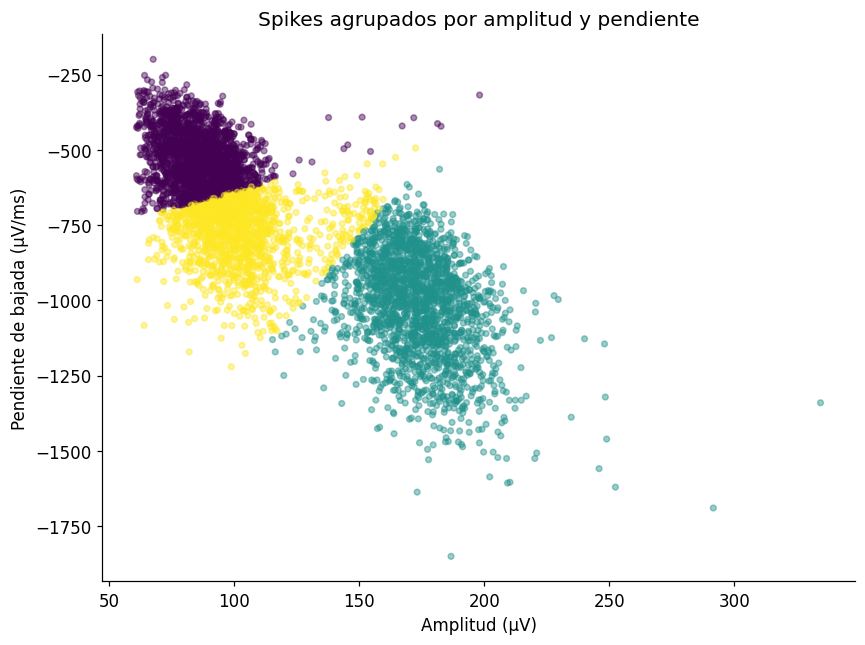

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Organizar las características:
# cada fila = un spike
# columna 1 = amplitud
# columna 2 = pendiente
caracteristicas = np.column_stack((amplitudes, pendientes))

print("Dimensiones:", caracteristicas.shape)


# 2. Estandarizar antes de K-means
escalador = StandardScaler()
caracteristicas_std = escalador.fit_transform(caracteristicas)


# 3. Agrupar en 3 unidades
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas = kmeans.fit_predict(caracteristicas_std)


# 4. Gráfico de dispersión con los grupos encontrados
plt.figure(figsize=(8, 6))

plt.scatter(
    amplitudes,
    pendientes,
    c=etiquetas,
    s=14,
    alpha=0.45
)

plt.xlabel("Amplitud (µV)")
plt.ylabel("Pendiente de bajada (µV/ms)")
plt.title("Spikes agrupados por amplitud y pendiente")

plt.tight_layout()


# 5. Ver cuántos spikes quedaron en cada grupo
for unidad in np.unique(etiquetas):
    print(f"Unidad {unidad}: {np.sum(etiquetas == unidad)} spikes")

print("Total de etiquetas:", len(etiquetas))

In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2034       32        1
           0          2     1429      536
           2        123     1237       63

  Acierto   69.8%  ████████████████████········

  ▸ La separación no funciona. ¿Sobre qué característica estás
    agrupando? ¿Basta con esa?


Unidad 0: 2176 spikes
Unidad 1: 467 spikes
Unidad 2: 2818 spikes


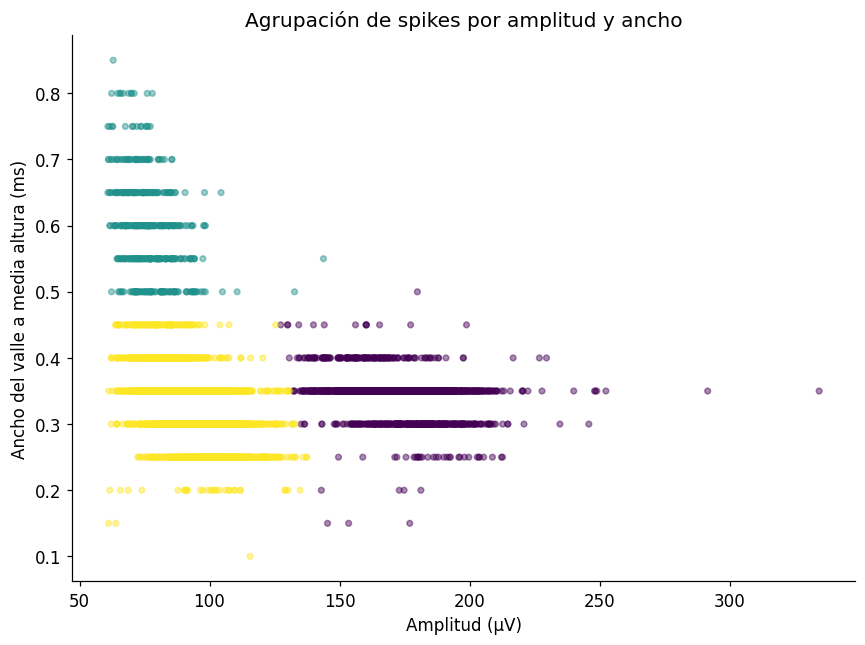

In [ ]:
#codigo solo para probar que las dos caracteristicas que elegimos no eran suficiente. codigo con ancho en vez de bajada
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

dt_ms = 1000 / fs

amplitudes = []
anchos = []

for forma in formas:


    minimo = np.min(forma)
    amplitud = -minimo

    amplitudes.append(amplitud)


    # Índice donde está el mínimo
    i_min = np.argmin(forma)

    # Estimar la línea base usando las primeras muestras
    linea_base = np.mean(forma[:5])

    # Nivel correspondiente a la mitad del valle
    media_altura = linea_base + (minimo - linea_base) / 2

    # Buscar hacia la izquierda desde el mínimo
    izquierda = i_min
    while izquierda > 0 and forma[izquierda] <= media_altura:
        izquierda -= 1

    # Buscar hacia la derecha desde el mínimo
    derecha = i_min
    while derecha < len(forma) - 1 and forma[derecha] <= media_altura:
        derecha += 1

    # Convertir el ancho de muestras a milisegundos
    ancho = (derecha - izquierda) * dt_ms

    anchos.append(ancho)


# Pasar a arrays
amplitudes = np.array(amplitudes)
anchos = np.array(anchos)


caracteristicas = np.column_stack((amplitudes, anchos))


# Estandarizar
escalador = StandardScaler()
caracteristicas_std = escalador.fit_transform(caracteristicas)


# K-means con 3 grupos
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas = kmeans.fit_predict(caracteristicas_std)

# Gráfico


plt.figure(figsize=(8, 6))

plt.scatter(
    amplitudes,
    anchos,
    c=etiquetas,
    s=14,
    alpha=0.45
)

plt.xlabel("Amplitud (µV)")
plt.ylabel("Ancho del valle a media altura (ms)")
plt.title("Agrupación de spikes por amplitud y ancho")

plt.tight_layout()


# Cuántos spikes quedaron en cada grupo
for unidad in np.unique(etiquetas):
    print(f"Unidad {unidad}: {np.sum(etiquetas == unidad)} spikes")

In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           0       2138       36        2
           2         20     2657      137
           1          1        5      461

  Acierto   96.3%  ███████████████████████████·

  ▸ Separación correcta.


In [ ]:
#en efecto es mas accurate separarlos por ancho del valle y amplitud del spike. Separa claramente la actividad de las 3 neuronas

Grupo 0: 1791 spikes
Grupo 1: 2141 spikes
Grupo 2: 1529 spikes


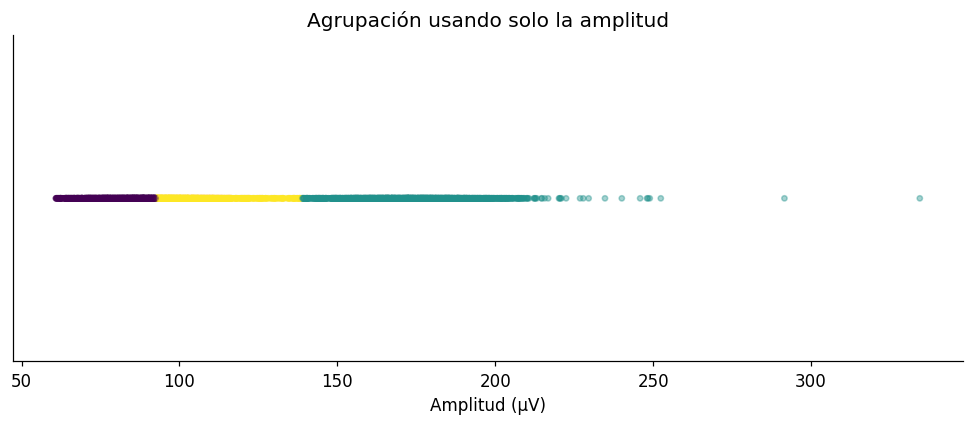

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt


# 1. Calcular amplitud de cada spike


amplitudes = []

for forma in formas:
    amplitud = -np.min(forma)   # magnitud del pico negativo, en µV
    amplitudes.append(amplitud)

amplitudes = np.array(amplitudes)


# 2. Preparar los datos para K-means
# Cada fila corresponde a un spike


X_amp = amplitudes.reshape(-1, 1)



# 3. Separar en 3 grupos usando solo amplitud


kmeans_amp = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas_amp = kmeans_amp.fit_predict(X_amp)


# 4. Graficar la amplitud de los spikes


plt.figure(figsize=(9, 4))

plt.scatter(
    amplitudes,
    np.zeros_like(amplitudes),
    c=etiquetas_amp,
    s=12,
    alpha=0.4
)

plt.xlabel("Amplitud (µV)")
plt.yticks([])
plt.title("Agrupación usando solo la amplitud")

plt.tight_layout()


# 5. Número de spikes por grupo


for u in np.unique(etiquetas_amp):
    print(f"Grupo {u}: {np.sum(etiquetas_amp == u)} spikes")

In [ ]:
# Verificación usando SOLO amplitud
acierto_amp = v.verificar_unidades(indices / fs, etiquetas_amp)

  Spikes tuyos emparejados con uno real: 5457
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2106       33        2
           2         53     1424       52
           0          0     1241      546

  Acierto   74.7%  █████████████████████·······

  ▸ Casi. Dos de tus unidades se están mezclando: mira la matriz
    y pregúntate qué característica NO estás usando.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?



- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud |74.7%|
| amplitud + ancho |96.3%|

_Explicación: Usando solo la amplitud obtuvimos un acierto de 74.6%, porque dos de las neuronas tienen spikes de tamaños parecidos y quedan mezcladas. Al agregar el ancho del valle, el acierto subió a 96.3%, una mejora de 21.7 puntos porcentuales. El ancho ayudó porque agrega información sobre la forma y duración del spike, permitiendo separar eventos que tienen amplitudes similares. En la matriz final todavía se observa un poco de confusión principalmente entre grupo 1 y 2, pero es mucho menor que usando solo amplitud.

---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

In [ ]:
#a

def calcular_isi(tiempos_s, limite_ms=2.0):
    """Devuelve los ISI en ms y la fracción menor al límite."""

    isi_ms = np.diff(tiempos_s) * 1000

    if len(isi_ms) == 0:
        return isi_ms, np.nan

    fraccion = np.mean(isi_ms < limite_ms)

    return isi_ms, fraccion

In [ ]:
isi_todos, viol_todos = calcular_isi(tiempos)

print(f"ISI totales: {len(isi_todos)}")
print(f"Fracción de ISI < 2 ms: {viol_todos:.4f}")
print(f"Porcentaje de violaciones: {viol_todos*100:.2f}%")

ISI totales: 5460
Fracción de ISI < 2 ms: 0.0079
Porcentaje de violaciones: 0.79%


In [ ]:
# b

for unidad in np.unique(etiquetas):

    tiempos_unidad = tiempos[etiquetas == unidad]

    # Por seguridad, mantenerlos ordenados
    tiempos_unidad = np.sort(tiempos_unidad)

    isi_u, viol_u = calcular_isi(tiempos_unidad)

    print(
        f"Unidad {unidad}: "
        f"{len(tiempos_unidad)} spikes · "
        f"violaciones < 2 ms = {viol_u*100:.2f}%"
    )

Unidad 0: 2176 spikes · violaciones < 2 ms = 0.09%
Unidad 1: 467 spikes · violaciones < 2 ms = 0.00%
Unidad 2: 2818 spikes · violaciones < 2 ms = 0.00%


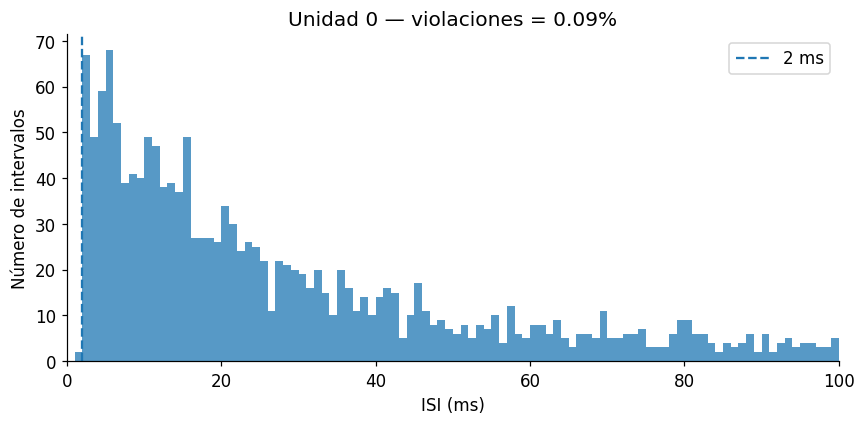

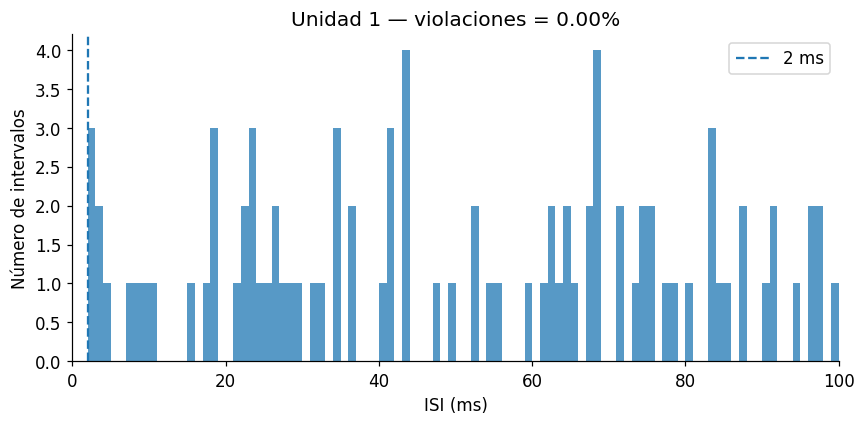

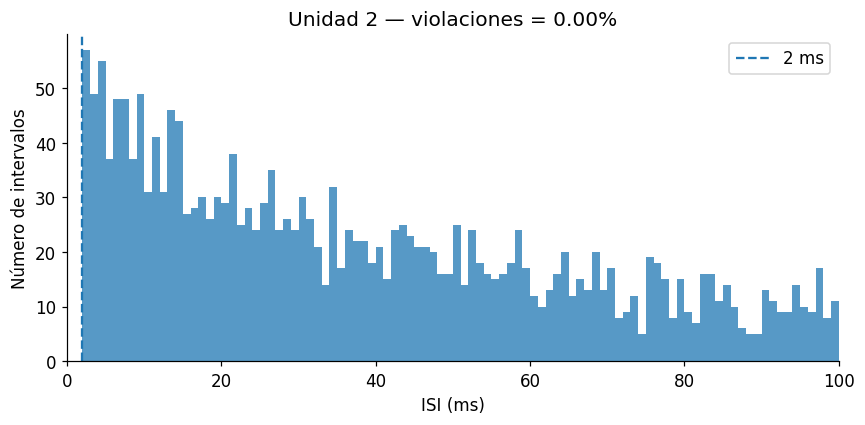

In [ ]:
# c

bins = np.arange(0, 101, 1)

for unidad in np.unique(etiquetas):

    tiempos_unidad = np.sort(tiempos[etiquetas == unidad])

    isi_u, viol_u = calcular_isi(tiempos_unidad)

    plt.figure(figsize=(8, 4))

    plt.hist(
        isi_u,
        bins=bins,
        alpha=0.75
    )

    # Línea del período refractario
    plt.axvline(
        2,
        linestyle="--",
        linewidth=1.5,
        label="2 ms"
    )

    plt.xlim(0, 100)

    plt.xlabel("ISI (ms)")
    plt.ylabel("Número de intervalos")

    plt.title(
        f"Unidad {unidad} — violaciones = {viol_u*100:.2f}%"
    )

    plt.legend()
    plt.tight_layout()

In [ ]:
# d
indices_04 = detectar_spikes(AP, fs, k=4.5, muerto_ms=0.4)
tiempos_04 = indices_04 / fs

In [ ]:
isi_todos_04, viol_todos_04 = calcular_isi(tiempos_04)

print("DETECCIÓN CON 0.4 ms")
print(f"Spikes: {len(tiempos_04)}")
print(f"Violaciones globales < 2 ms: {viol_todos_04*100:.2f}%")

DETECCIÓN CON 0.4 ms
Spikes: 5526
Violaciones globales < 2 ms: 2.01%


In [ ]:
# esto es con amplitud y ancho del valle


# Extraer formas para muerto_ms = 0.4

formas_04 = []
indices_validos_04 = []

for idx in indices_04:

    inicio = idx - pre
    fin = idx + post

    if inicio >= 0 and fin <= len(AP):
        formas_04.append(AP[inicio:fin])
        indices_validos_04.append(idx)

formas_04 = np.array(formas_04)
indices_04 = np.array(indices_validos_04)

tiempos_04 = indices_04 / fs

In [ ]:
dt_ms = 1000 / fs

amplitudes_04 = []
anchos_04 = []

for forma in formas_04:

    minimo = np.min(forma)
    amplitudes_04.append(-minimo)

    i_min = np.argmin(forma)

    linea_base = np.mean(forma[:5])
    media_altura = linea_base + (minimo - linea_base) / 2

    izquierda = i_min
    while izquierda > 0 and forma[izquierda] <= media_altura:
        izquierda -= 1

    derecha = i_min
    while derecha < len(forma) - 1 and forma[derecha] <= media_altura:
        derecha += 1

    ancho = (derecha - izquierda) * dt_ms
    anchos_04.append(ancho)

amplitudes_04 = np.array(amplitudes_04)
anchos_04 = np.array(anchos_04)

In [ ]:
caracteristicas_04 = np.column_stack(
    (amplitudes_04, anchos_04)
)

escalador_04 = StandardScaler()
caracteristicas_std_04 = escalador_04.fit_transform(
    caracteristicas_04
)

kmeans_04 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

etiquetas_04 = kmeans_04.fit_predict(
    caracteristicas_std_04
)

In [ ]:
#final del d
print("VIOLACIONES POR UNIDAD CON muerto_ms = 0.4 ms")

for unidad in np.unique(etiquetas_04):

    tiempos_unidad = np.sort(
        tiempos_04[etiquetas_04 == unidad]
    )

    isi_u, viol_u = calcular_isi(tiempos_unidad)

    print(
        f"Unidad {unidad}: "
        f"{len(tiempos_unidad)} spikes · "
        f"violaciones < 2 ms = {viol_u*100:.2f}%"
    )

VIOLACIONES POR UNIDAD CON muerto_ms = 0.4 ms
Unidad 0: 2845 spikes · violaciones < 2 ms = 0.04%
Unidad 1: 2206 spikes · violaciones < 2 ms = 1.36%
Unidad 2: 475 spikes · violaciones < 2 ms = 0.63%


**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | 0.79%|
| unidad 1 |0.09%|
| unidad 2 |0.09%|
| unidad 3 | 0.0%|

¿Alguna unidad está contaminada? ¿Cuál y por qué?
La unidad 0 es la unica que tiene indicios de contaminacion , aunque bastante bajas, a 0.09% de violaciones del refractario, mientras que la 1 & 2 tienen 0.0.


¿Qué pasó al bajar el período muerto a 0,4 ms?
En 0 la contaminacion baja a 0.04% (pero aun presente). La unidad 1 sube a 1.36% y la 2 a 0.63%.

---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [ ]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs

#inicios     = ____     # instante de inicio de cada ENSAYO, en segundos
#condiciones = ____     # la condición de cada ensayo ('A', 'B' o 'C')
#t_pre       = ____     # cuánto dura el pre-estímulo dentro del ensayo, en segundos
#t_est       = ____     # cuánto dura el estímulo, en segundos

In [ ]:
import h5py
import numpy as np

with h5py.File(ARCHIVO, "r") as f:

    est = f["estimulos"]

    # Variables que pide el ejercicio
    inicios = est["tiempo_inicio_s"][:]

    # Convertir de bytes (b'A') a texto ('A')
    condiciones = est["condicion"][:].astype(str)

    t_pre = est.attrs["duracion_pre_s"]
    t_est = est.attrs["duracion_estimulo_s"]
    t_post = est.attrs["duracion_post_s"]

# Responder las preguntas


# Número total de ensayos
print("Número total de ensayos:", len(inicios))

# Número de ensayos por condición
valores, conteos = np.unique(condiciones, return_counts=True)

print("\nEnsayos por condición:")
for condicion, n in zip(valores, conteos):
    print(f"Condición {condicion}: {n}")


# Duración total de un ensayo
duracion_ensayo = t_pre + t_est + t_post

print(f"\nDuración de cada ensayo: {duracion_ensayo:.1f} s")
print(f"El estímulo empieza {t_pre:.1f} s después del inicio del ensayo")
print(f"Duración del estímulo: {t_est:.1f} s")


# Revisar el orden de las condiciones
print("\nPrimeras 20 condiciones:")
print(condiciones[:20])

Número total de ensayos: 60

Ensayos por condición:
Condición A: 20
Condición B: 20
Condición C: 20

Duración de cada ensayo: 3.0 s
El estímulo empieza 1.0 s después del inicio del ensayo
Duración del estímulo: 0.5 s

Primeras 20 condiciones:
['B' 'B' 'C' 'A' 'A' 'A' 'C' 'A' 'C' 'B' 'B' 'B' 'A' 'C' 'C' 'B' 'C' 'C'
 'A' 'C']


In [ ]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [ ]:
#def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    #"""Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    # Su código aquí.
   #...


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
#etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
#alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [ ]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""

    resultado = []

    for inicio in inicios:

        # El estímulo empieza t_pre segundos después del inicio del ensayo
        inicio_estimulo = inicio + t_pre

        # Pasar los spikes a tiempo relativo al estímulo
        relativos = tiempos - inicio_estimulo

        # Quedarse solo con la ventana pedida
        m = (
            (relativos >= ventana[0]) &
            (relativos < ventana[1])
        )

        resultado.append(relativos[m])

    return resultado

In [ ]:
etiquetas = np.asarray(etiquetas)

alineados = {
    u: alinear(
        tiempos[etiquetas == u],
        inicios,
        t_pre
    )
    for u in np.unique(etiquetas)
}

print("Unidades:", alineados.keys())
print("Número de ensayos por unidad:", len(alineados[np.unique(etiquetas)[0]]))

Unidades: dict_keys([np.int32(0), np.int32(1), np.int32(2)])
Número de ensayos por unidad: 60


In [ ]:
# Elegir una unidad y un ensayo cualquiera
u = np.unique(etiquetas)[0]
ensayo = 10

# Tiempos absolutos de los spikes de esa unidad
tiempos_u = tiempos[etiquetas == u]

# Inicio absoluto del estímulo
inicio_estimulo = inicios[ensayo] + t_pre

# Buscar a mano los spikes entre -1 y +2 s respecto al estímulo
m = (
    (tiempos_u >= inicio_estimulo - 1.0) &
    (tiempos_u < inicio_estimulo + 2.0)
)

# Restar el instante del estímulo
manual = tiempos_u[m] - inicio_estimulo

# Resultado que dio la función
automatico = alineados[u][ensayo]

print("Inicio del ensayo:", inicios[ensayo], "s")
print("Inicio del estímulo:", inicio_estimulo, "s")

print("\nCálculo manual:")
print(manual)

print("\nResultado de alinear():")
print(automatico)

print("\n¿Coinciden?", np.allclose(manual, automatico))

Inicio del ensayo: 60.0 s
Inicio del estímulo: 61.0 s

Cálculo manual:
[-0.9671  -0.93105 -0.6413  -0.47435 -0.41715 -0.3991  -0.37765 -0.18795
 -0.0908  -0.07     0.0034   0.01485  0.0475   0.11005  0.1121   0.1272
  0.1311   0.1673   0.17075  0.1774   0.1817   0.18445  0.2048   0.21315
  0.21725  0.2246   0.23605  0.23965  0.24835  0.3164   0.3186   0.33265
  0.33565  0.35415  0.3639   0.37135  0.37525  0.38265  0.3871   0.4015
  0.4121   0.45895  0.4788   0.49505  0.49755  0.5769   0.7439   0.7932
  0.899    0.90475  1.1132   1.41515  1.57985  1.7583   1.8504 ]

Resultado de alinear():
[-0.9671  -0.93105 -0.6413  -0.47435 -0.41715 -0.3991  -0.37765 -0.18795
 -0.0908  -0.07     0.0034   0.01485  0.0475   0.11005  0.1121   0.1272
  0.1311   0.1673   0.17075  0.1774   0.1817   0.18445  0.2048   0.21315
  0.21725  0.2246   0.23605  0.23965  0.24835  0.3164   0.3186   0.33265
  0.33565  0.35415  0.3639   0.37135  0.37525  0.38265  0.3871   0.4015
  0.4121   0.45895  0.4788   0.49505  0.4

In [ ]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.

In [ ]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:
- ¿Qué unidad responde al estímulo y cuál no?

En la grafica de abajo se puede ver como la unidad 0 responde al estiulo (entre 0 y 0.5 se ve un aumento de disparos). La unidad 2 ta,bien muestra una respuesta (no tan fuerte), y la unidad 1 no muestra respuesta.


- ¿Alguna responde solo a una de las tres condiciones?

La unidad 2 muestra respuesta solo a la condicion B, con un aumento de disparos muy claro en comparacion con la condicion A y C.


- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

En la unidad 0 se ven claros disparos en todas las condiciones, mientras que en la unidad 2 aunque hay respuesta en todas las condiciones, es mas fuerte en la B.

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

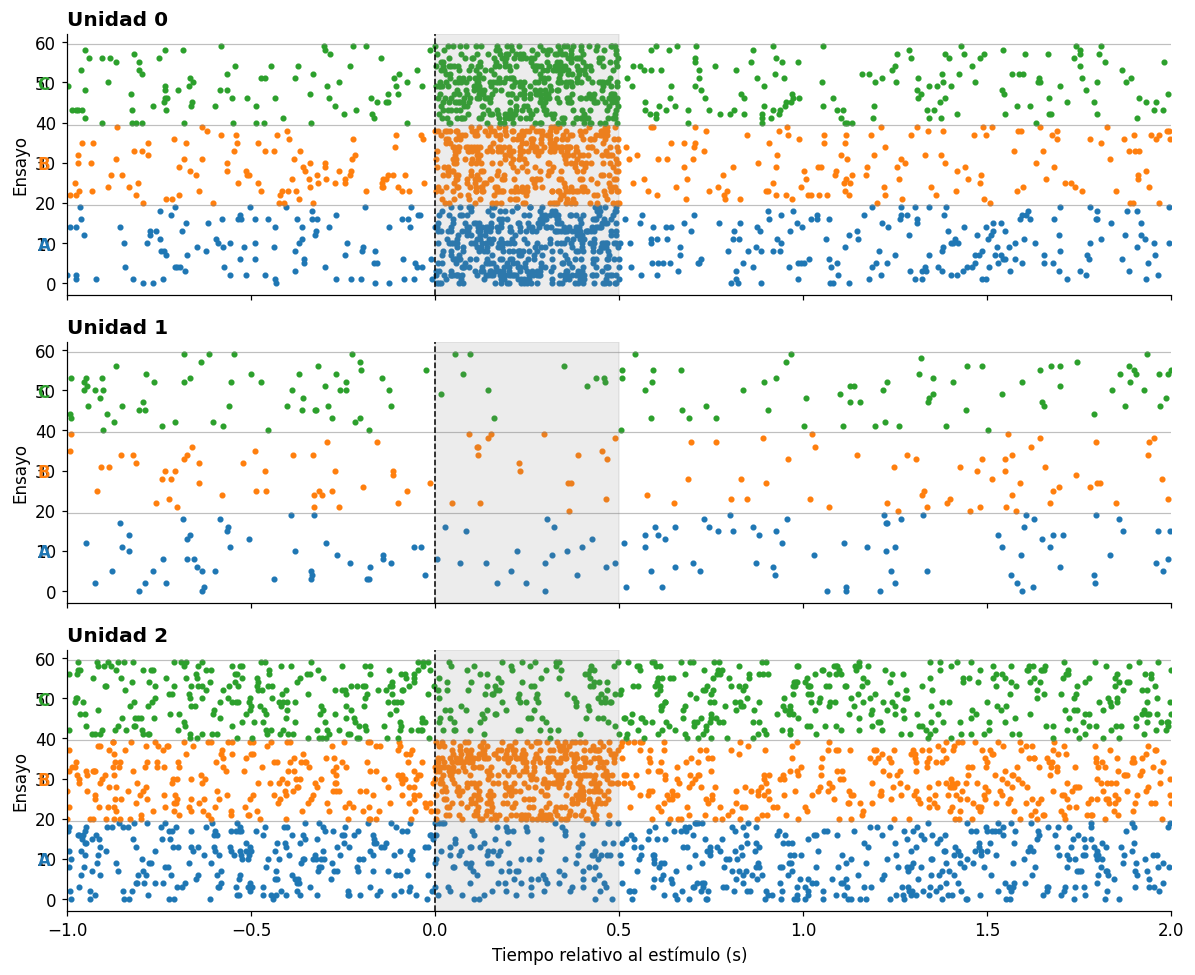

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Unidades y condiciones presentes
unidades = np.unique(etiquetas)
conds = ["A", "B", "C"]

# Un color por condición
colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}

fig, axes = plt.subplots(
    len(unidades), 1,
    figsize=(11, 9),
    sharex=True
)

for ax, u in zip(axes, unidades):

    fila = 0

    for condicion in conds:

        # Índices de los ensayos que pertenecen a esta condición
        ensayos_cond = np.where(condiciones == condicion)[0]

        inicio_bloque = fila

        for ensayo in ensayos_cond:

            # Spikes de esta unidad en este ensayo,
            # ya expresados en tiempo relativo al estímulo
            spikes = alineados[u][ensayo]

            # Una fila por ensayo
            ax.scatter(
                spikes,
                np.full(len(spikes), fila),
                s=9,
                color=colores[condicion]
            )

            fila += 1

        # Separación visual entre condiciones
        ax.axhline(fila - 0.5, color="gray", lw=0.8, alpha=0.5)

        # Escribir el nombre de la condición al lado del bloque
        centro = (inicio_bloque + fila - 1) / 2
        ax.text(
            -1.08,
            centro,
            condicion,
            color=colores[condicion],
            fontweight="bold",
            va="center"
        )

    # Ventana durante la cual estuvo presente el estímulo
    ax.axvspan(
        0,
        t_est,
        alpha=0.15,
        color="gray",
        label="Estímulo"
    )

    # Marcar el inicio del estímulo
    ax.axvline(0, color="black", ls="--", lw=1)

    ax.set_ylabel("Ensayo")
    ax.set_title(f"Unidad {u}", loc="left", fontweight="bold")
    ax.set_xlim(-1, 2)


axes[-1].set_xlabel("Tiempo relativo al estímulo (s)")

plt.tight_layout()

**Lo que leemos en el raster:**

---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?


Nosotras eligiriamos el bon de 20 ms, ya que este permite ver como la unidad 2 aumenta su tasa de disparo en la condicion B, sin tanto ruido.

El bin de 200ms esta promediando lso disparos de un intervalo mas largo, haciendo que el pico se vea mas bajo.

In [ ]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """
    Calcula un PSTH y devuelve los centros de los bins
    y la tasa de disparo en Hz.
    """

    # Bordes de los bins
    bordes = np.arange(
        ventana[0],
        ventana[1] + ancho_bin_s,
        ancho_bin_s
    )

    # Juntar los spikes de todos los ensayos
    todos_spikes = np.concatenate(ensayos_alineados)

    # Contar spikes en cada bin
    cuentas, _ = np.histogram(todos_spikes, bins=bordes)

    # Número de ensayos
    n_ensayos = len(ensayos_alineados)

    # Convertir a tasa de disparo en Hz
    tasa = cuentas / (n_ensayos * ancho_bin_s)

    # Centro de cada bin
    centros = (bordes[:-1] + bordes[1:]) / 2

    return centros, tasa

In [ ]:

#comprobando

u = np.unique(etiquetas)[1]

centros, tasa = psth(
    alineados[u],
    ventana=(-1.0, 2.0),
    ancho_bin_s=0.05
)

print("Unidad usada:", u)
print("Primeros centros:", centros[:5])
print("Primeras tasas:", tasa[:5])

Unidad usada: 1
Primeros centros: [-0.975 -0.925 -0.875 -0.825 -0.775]
Primeras tasas: [2.33333333 4.         2.66666667 2.33333333 2.33333333]


In [ ]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


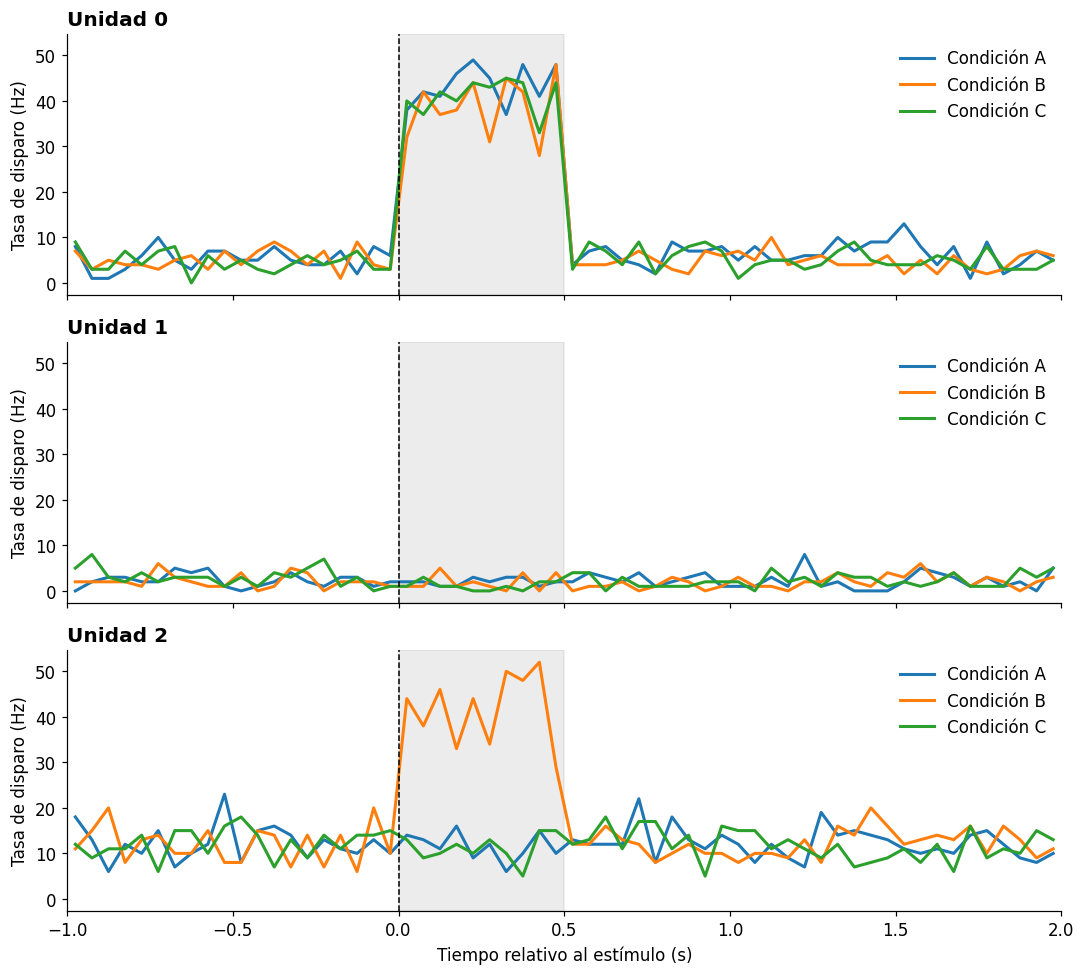

In [ ]:
# Ejercicios M2 y M3: su código aquí.

#M2
# Condiciones y unidades presentes

import numpy as np
import matplotlib.pyplot as plt
conds = np.unique(condiciones)
unidades = np.unique(etiquetas)

colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:green"
}

fig, axes = plt.subplots(
    len(unidades), 1,
    figsize=(10, 9),
    sharex=True,
    sharey=True
)

for ax, u in zip(axes, unidades):

    for cond in conds:

        # Qué ensayos pertenecen a esta condición
        idx_cond = np.where(condiciones == cond)[0]

        # Tomar solamente esos ensayos de esta unidad
        ensayos_cond = [alineados[u][i] for i in idx_cond]

        # PSTH con bins de 50 ms
        centros, tasa = psth(
            ensayos_cond,
            ventana=(-1.0, 2.0),
            ancho_bin_s=0.05
        )

        ax.plot(
            centros,
            tasa,
            label=f"Condición {cond}",
            color=colores[cond],
            lw=2
        )

    # Ventana donde está presente el estímulo
    ax.axvspan(0, t_est, color="gray", alpha=0.15)

    # Inicio del estímulo
    ax.axvline(0, color="black", ls="--", lw=1)

    ax.set_title(f"Unidad {u}", loc="left", fontweight="bold")
    ax.set_ylabel("Tasa de disparo (Hz)")
    ax.set_xlim(-1, 2)
    ax.legend(frameon=False)

axes[-1].set_xlabel("Tiempo relativo al estímulo (s)")

plt.tight_layout()





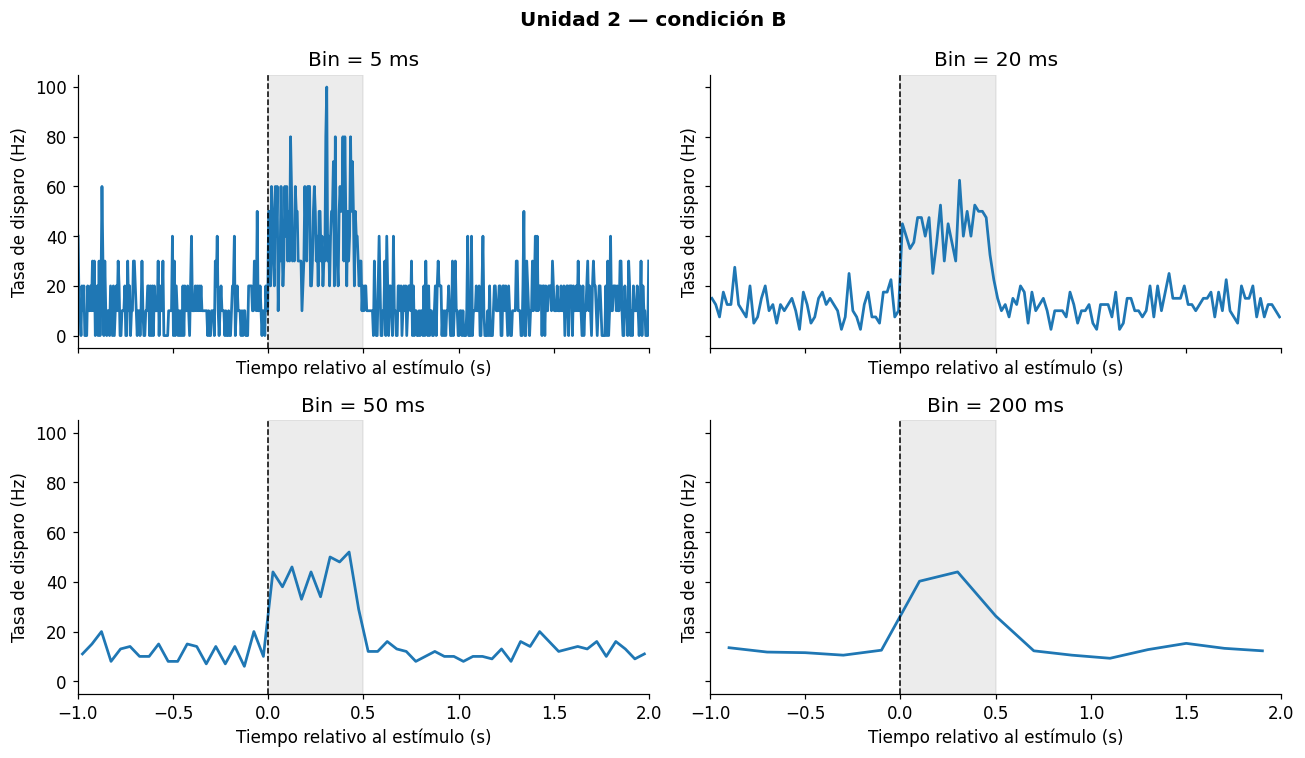

In [ ]:
# M3
# ELEGIMOS CONDICION B DE UNIDAD DOS PORQUE SE VE UNA RESPUESTA MUY CLARA Y PERMITE VER MEJOR EL EFECTO DEL BIN, COMPARADO A SI NOS TOCARA COMBINAR LAS 3 CONDICIONES Y PROMEDIAR
unidad_responde = 2

# Ensayos de condición B
idx_B = np.where(condiciones == "B")[0]

ensayos_B = [
    alineados[unidad_responde][i]
    for i in idx_B
]

bins_ms = [5, 20, 50, 200]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 7),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, ancho_ms in zip(axes, bins_ms):

    centros, tasa = psth(
        ensayos_B,
        ventana=(-1.0, 2.0),
        ancho_bin_s=ancho_ms / 1000
    )

    ax.plot(centros, tasa, lw=1.8)

    # Ventana del estímulo
    ax.axvspan(0, t_est, color="gray", alpha=0.15)

    # Inicio del estímulo
    ax.axvline(0, color="black", ls="--", lw=1)

    ax.set_title(f"Bin = {ancho_ms} ms")
    ax.set_xlim(-1, 2)

    ax.set_xlabel("Tiempo relativo al estímulo (s)")
    ax.set_ylabel("Tasa de disparo (Hz)")

fig.suptitle(
    "Unidad 2 — condición B",
    fontweight="bold"
)

plt.tight_layout()

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

   # JUSTIFICACION

   Elegimos normalizar cada fila por su máximo porque las unidades tienen tasas de disparo bastante diferentes y así se puede ver mejor el patrón de respuesta de cada una. La desventaja es que ya no podemos comparar directamente cuál neurona dispara más, y por eso la barra de color no está en Hz sino entre 0 y 1. Usamos `magma` porque es una escala secuencial y permite representar de forma clara valores que van de menor a mayor. Además, evitamos `jet` porque puede crear cambios visuales artificiales y hacer que diferencias pequeñas parezcan más importantes de lo que realmente son. Mantuvimos bins de 20 ms porque fue el tamaño que mejor equilibró resolución temporal y ruido en el PSTH. Finalmente, marcamos el inicio y la duración del estímulo para poder relacionar fácilmente los cambios en actividad con el momento en que se presentó.


**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

Sí. Se ve que la unidad 0 responde en las tres condiciones, porque aumenta claramente su actividad durante el estímulo. La unidad 2 responde principalmente a la condición B, donde aparece un aumento marcado entre 0 y 0.5 s. La unidad 1 no muestra una respuesta clara asociada al estímulo. Como cada fila está normalizada por su propio máximo, los colores permiten comparar cambios dentro de cada fila, pero no comparar directamente cuánto dispara una unidad frente a otra.

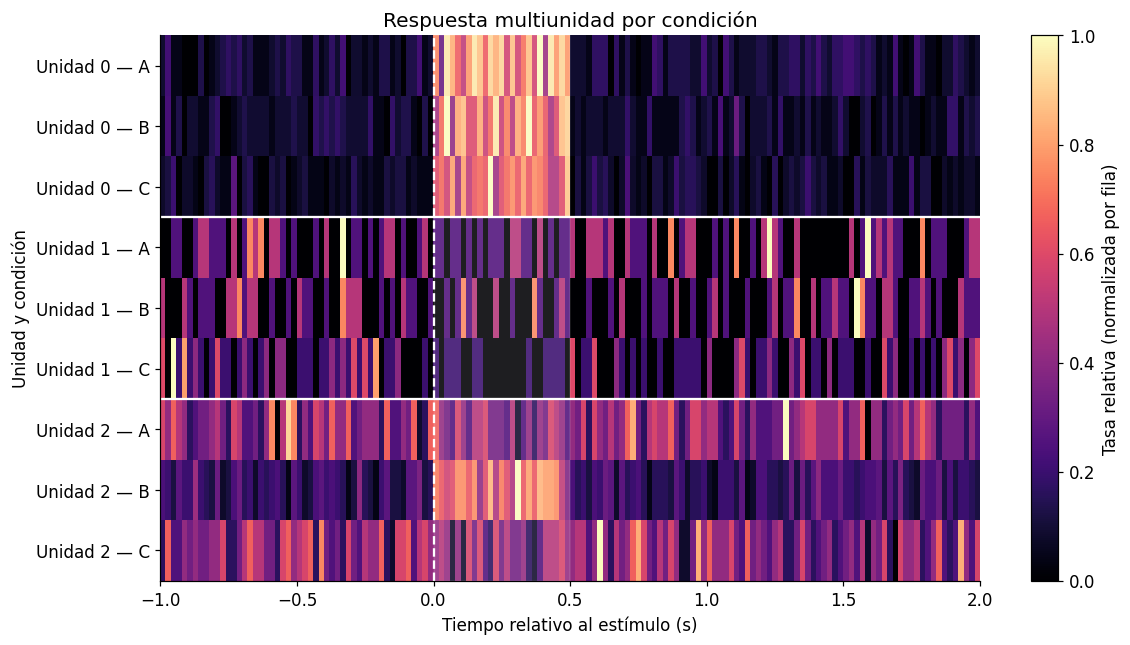

In [ ]:
# Su código aquí.

# Parámetros
ventana = (-1.0, 2.0)
ancho_bin = 0.020          # 20 ms
unidades_orden = [0, 1, 2]
condiciones_orden = ["A", "B", "C"]

filas = []
nombres_filas = []

# Construir un PSTH para cada combinación unidad-condición
for u in unidades_orden:

    for cond in condiciones_orden:

        # Ensayos que pertenecen a esta condición
        idx_cond = np.where(condiciones == cond)[0]

        # Ensayos alineados de esta unidad y condición
        ensayos_cond = [alineados[u][i] for i in idx_cond]

        # PSTH
        centros, tasa = psth(
            ensayos_cond,
            ventana=ventana,
            ancho_bin_s=ancho_bin
        )

        filas.append(tasa)
        nombres_filas.append(f"Unidad {u} — {cond}")


# Matriz original en Hz
matriz_hz = np.array(filas)

# Normalizar cada fila por su propio máximo
matriz_norm = np.zeros_like(matriz_hz)

for i in range(len(matriz_hz)):
    maximo = np.max(matriz_hz[i])

    if maximo > 0:
        matriz_norm[i] = matriz_hz[i] / maximo


# Heatmap

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    matriz_norm,
    aspect="auto",
    cmap="magma",
    vmin=0,
    vmax=1,
    extent=[
        ventana[0],
        ventana[1],
        len(nombres_filas) - 0.5,
        -0.5
    ]
)

# Etiquetas de las nueve filas
ax.set_yticks(np.arange(len(nombres_filas)))
ax.set_yticklabels(nombres_filas)

# Separar visualmente las tres unidades
ax.axhline(2.5, color="white", lw=1.5)
ax.axhline(5.5, color="white", lw=1.5)

# Inicio del estímulo
ax.axvline(0, color="white", ls="--", lw=1.5)

# Ventana durante la cual estuvo presente el estímulo
ax.axvspan(
    0,
    t_est,
    color="white",
    alpha=0.12
)

ax.set_xlabel("Tiempo relativo al estímulo (s)")
ax.set_ylabel("Unidad y condición")
ax.set_title("Respuesta multiunidad por condición")

# Barra de color
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Tasa relativa (normalizada por fila)")

plt.tight_layout()

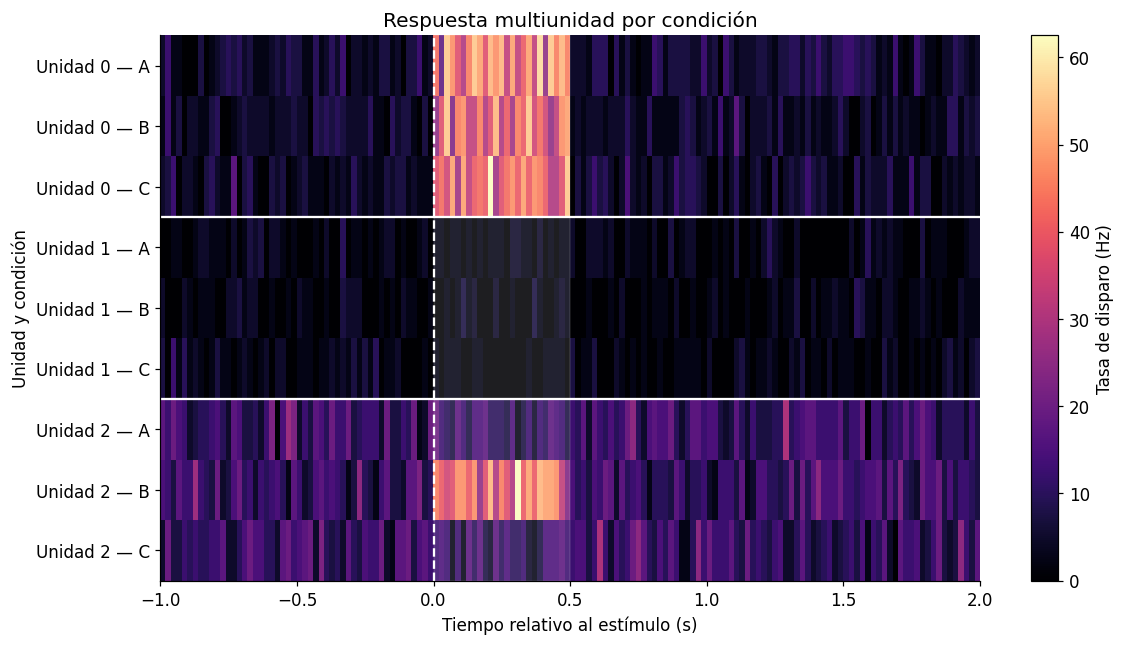

In [ ]:
#no prestar atencion. estoy probando como se veria el heat map si comparto la escala de color para las 9 filas.
# se ve mucho mas la actividad de las cosas esras
# Heatmap

ventana = (-1.0, 2.0)
ancho_bin = 0.020
unidades_orden = [0, 1, 2]
condiciones_orden = ["A", "B", "C"]

filas = []
nombres_filas = []

for u in unidades_orden:

    for cond in condiciones_orden:

        idx_cond = np.where(condiciones == cond)[0]

        ensayos_cond = [alineados[u][i] for i in idx_cond]

        centros, tasa = psth(
            ensayos_cond,
            ventana=ventana,
            ancho_bin_s=ancho_bin
        )

        filas.append(tasa)
        nombres_filas.append(f"Unidad {u} — {cond}")


# Matriz en Hz, SIN normalizar por fila
matriz_hz = np.array(filas)


fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    matriz_hz,
    aspect="auto",
    cmap="magma",
    extent=[
        ventana[0],
        ventana[1],
        len(nombres_filas) - 0.5,
        -0.5
    ]
)

# Etiquetas de las filas
ax.set_yticks(np.arange(len(nombres_filas)))
ax.set_yticklabels(nombres_filas)

# Separar las unidades
ax.axhline(2.5, color="white", lw=1.5)
ax.axhline(5.5, color="white", lw=1.5)

# Inicio del estímulo
ax.axvline(0, color="white", ls="--", lw=1.5)

# Ventana del estímulo
ax.axvspan(
    0,
    t_est,
    color="white",
    alpha=0.12
)

ax.set_xlabel("Tiempo relativo al estímulo (s)")
ax.set_ylabel("Unidad y condición")
ax.set_title("Respuesta multiunidad por condición")

# Barra de color ahora sí en Hz
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Tasa de disparo (Hz)")

plt.tight_layout()

In [ ]:
# se ve mucho mas que si lo normalizo cada fila, esto puede que pase porque el mismo color significa la misma tasa de disparos en todas las filas, por eso se ve la actividad de las neuronas mas claramente.

**Lo que el heatmap muestra y el PSTH escondía:** El heatmap permite ver las nueve combinaciones de unidad y condición al mismo tiempo. Hace más fácil notar que la unidad 0 responde de forma general a A, B y C, mientras que la unidad 2 responde de forma selectiva a B. También permite ver patrones temporales de la unidad 1 aunque su actividad real sea baja.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

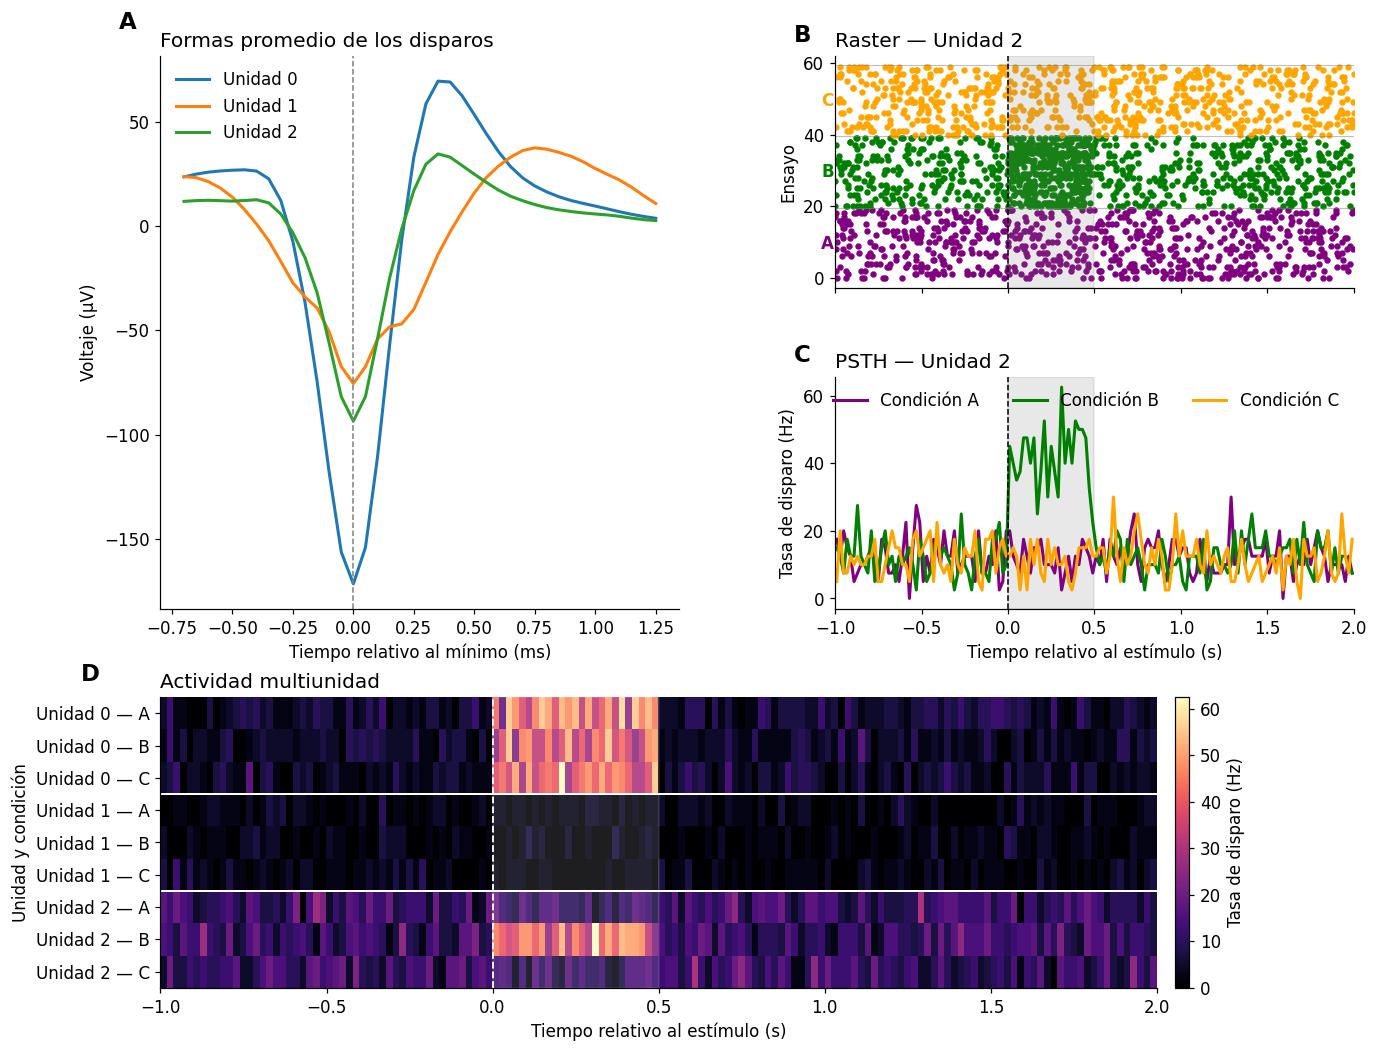

In [ ]:
# Su código aquí.

# FIGURA FINAL

unidad_responde = 2
ventana = (-1.0, 2.0)
ancho_bin = 0.020          # 20 ms

conds = ["A", "B", "C"]

colores_cond = {
    "A": "purple",
    "B": "green",
    "C": "orange"
}


# Preparar la figura
# A a la izquierda
# B y C apilados a la derecha
# D abajo ocupando todo el ancho


fig = plt.figure(figsize=(14, 11))

gs = fig.add_gridspec(
    3, 2,
    height_ratios=[1, 1, 1.25],
    hspace=0.35,
    wspace=0.30
)

axA = fig.add_subplot(gs[0:2, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 1], sharex=axB)
axD = fig.add_subplot(gs[2, :])


# PANEL A · Formas promedio de las tres unidades

pre_muestras = int(round(0.7e-3 * fs))

eje_ms = (
    np.arange(formas.shape[1]) - pre_muestras
) * 1000 / fs

for u in np.unique(etiquetas):

    forma_promedio = formas[etiquetas == u].mean(axis=0)

    axA.plot(
        eje_ms,
        forma_promedio,
        lw=2,
        label=f"Unidad {u}"
    )

axA.axvline(0, color="gray", ls="--", lw=1)

axA.set_xlabel("Tiempo relativo al mínimo (ms)")
axA.set_ylabel("Voltaje (µV)")
axA.set_title("Formas promedio de los disparos", loc="left")
axA.legend(frameon=False)


# PANEL B · Raster de la unidad 2


fila = 0

for cond in conds:

    idx_cond = np.where(condiciones == cond)[0]

    fila_inicio = fila

    for ensayo in idx_cond:

        spikes = alineados[unidad_responde][ensayo]

        axB.scatter(
            spikes,
            np.full(len(spikes), fila),
            s=10,
            color=colores_cond[cond]
        )

        fila += 1

    # Separación entre condiciones
    axB.axhline(
        fila - 0.5,
        color="gray",
        lw=0.7,
        alpha=0.5
    )

    # Nombre de la condición
    centro = (fila_inicio + fila - 1) / 2

    axB.text(
        -1.08,
        centro,
        cond,
        color=colores_cond[cond],
        fontweight="bold",
        va="center"
    )


# Estímulo: misma marca que en C y D
axB.axvspan(
    0,
    t_est,
    color="gray",
    alpha=0.18
)

axB.axvline(
    0,
    color="black",
    ls="--",
    lw=1
)

axB.set_ylabel("Ensayo")
axB.set_title("Raster — Unidad 2", loc="left")
axB.set_xlim(ventana)

# Ocultar etiquetas del eje x porque C está justo debajo
plt.setp(axB.get_xticklabels(), visible=False)


# PANEL C · PSTH de la unidad 2
# Tres condiciones


for cond in conds:

    idx_cond = np.where(condiciones == cond)[0]

    ensayos_cond = [
        alineados[unidad_responde][i]
        for i in idx_cond
    ]

    centros, tasa = psth(
        ensayos_cond,
        ventana=ventana,
        ancho_bin_s=ancho_bin
    )

    axC.plot(
        centros,
        tasa,
        color=colores_cond[cond],
        lw=2,
        label=f"Condición {cond}"
    )


axC.axvspan(
    0,
    t_est,
    color="gray",
    alpha=0.18
)

axC.axvline(
    0,
    color="black",
    ls="--",
    lw=1
)

axC.set_xlabel("Tiempo relativo al estímulo (s)")
axC.set_ylabel("Tasa de disparo (Hz)")
axC.set_title("PSTH — Unidad 2", loc="left")
axC.set_xlim(ventana)

axC.legend(
    frameon=False,
    ncol=3
)

# PANEL D · Heatmap multiunidad
# Escala compartida en Hz


filas_heatmap = []
nombres_filas = []

for u in [0, 1, 2]:

    for cond in conds:

        idx_cond = np.where(condiciones == cond)[0]

        ensayos_cond = [
            alineados[u][i]
            for i in idx_cond
        ]

        centros_h, tasa_h = psth(
            ensayos_cond,
            ventana=ventana,
            ancho_bin_s=ancho_bin
        )

        filas_heatmap.append(tasa_h)
        nombres_filas.append(f"Unidad {u} — {cond}")


# SIN normalización:
# todas las filas comparten la misma escala en Hz
matriz_hz = np.array(filas_heatmap)


im = axD.imshow(
    matriz_hz,
    aspect="auto",
    cmap="magma",
    extent=[
        ventana[0],
        ventana[1],
        len(nombres_filas) - 0.5,
        -0.5
    ]
)

axD.set_yticks(np.arange(len(nombres_filas)))
axD.set_yticklabels(nombres_filas)

# Separaciones entre unidades
axD.axhline(2.5, color="white", lw=1.3)
axD.axhline(5.5, color="white", lw=1.3)

# Misma marca del estímulo
axD.axvspan(
    0,
    t_est,
    color="white",
    alpha=0.12
)

axD.axvline(
    0,
    color="white",
    ls="--",
    lw=1.2
)

axD.set_xlabel("Tiempo relativo al estímulo (s)")
axD.set_ylabel("Unidad y condición")
axD.set_title("Actividad multiunidad", loc="left")


# Barra de color en Hz
cbar = fig.colorbar(
    im,
    ax=axD,
    pad=0.015
)

cbar.set_label("Tasa de disparo (Hz)")


# Letras de los paneles


for ax, letra in zip(
    [axA, axB, axC, axD],
    ["A", "B", "C", "D"]
):

    ax.text(
        -0.08,
        1.04,
        letra,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom"
    )

# Guardar

plt.savefig(
    "figuras/figura_final.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

**Pregunta P2.** El pie de la figura:

> **Figura 1.** … Respuestas neuronales del registro extracelular. A) Forma de ondas promedio de tres uniades (0,1,2), identificadas por la amplitud y el ancho de los potenciales de accion
b)Raster de Unidad 2, tres ensayos (A,B,C) separados por condicion experimental
c)PTSH de la unidad 2, demuestra la tasa de disparo en funcion del tiempo
D)Hetamap de la tasa de disparo de las tres uniadades (0,1,2). Linea punteada blacno demostrando el inicio del estimulo, y la zona entre 0.0 y 0.5 demonstrando duracion

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

La grabación reveló tres unidades neuronales con perfiles de respuesta distintos en las diferentes condiciones experimentales. La Unidad 0 mostró un aumento en la frecuencia de disparo tras el inicio del estímulo en las tres condiciones (A, B y C), alcanzando frecuencias máximas de aproximadamente 50-60 Hz. Sin embargo, no mostró preferencia evidente por ninguna condición específica, lo que sugiere un perfil general de respuesta al estímulo en lugar de selectividad de condición. Por el contrario, la Unidad 1 mantuvo una frecuencia de disparo consistentemente baja antes, durante y después de la estimulación, sin un aumento claro de la actividad en ninguna condición, lo que indica la ausencia de una respuesta evidente provocada por el estímulo. La Unidad 2 mostró actividad basal espontánea y un aumento en la frecuencia de disparo durante la condición B, alcanzando ~40-50 Hz. Las respuestas a las condiciones A y C fueron comparativamente menores, lo que sugiere una sensibilidad preferencial a la condición B. El procedimiento de clasificación de picos alcanzó una precisión del 96,3 %, con tasas de violación del período refractario de solo el 0,09 % para la Unidad 0 y del 0,0 % para las Unidades 1 y 2. En general, estos resultados identifican tres patrones de respuesta funcional distintos: una neurona con amplia respuesta a estímulos (Unidad 0), una neurona sin respuesta evidente inducida por estímulos (Unidad 1) y una neurona que responde a la condición B (Unidad 2).

**Resultados**

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:** Estoy trabajando en Python con una señal filtrada de potenciales de acción llamada AP. Ya tengo un arreglo indices con los índices de los spikes detectados y tiempos = indices / fs. Quiero hacer una figura de control en una ventana de 200 ms, de 31.0 a 31.2 s.
La figura debe mostrar la señal AP, una línea horizontal con el valor del umbral y un triángulo exactamente sobre el mínimo de cada spike detectado dentro de esa ventana

**Respuesta del modelo:** codigo sin error

**Qué estaba mal:** El código de la gráfica sí funcionaba, pero al revisarla visualmente vimos un spike evidente sin marcador. El problema no estaba en plt.plot, sino en las detecciones que recibía la gráfica: con un período muerto de 1.5 ms, algunos eventos muy cercanos podían quedar descartados.

**Cómo lo corregimos:** Probamos un período muerto más corto para permitir detectar eventos cercanos de neuronas diferentes. Finalmente usamos muerto_ms = 0.3 y volvimos a generar indices, tiempos y la figura. Comprobamos visualmente que los triángulos quedaran sobre los mínimos de los spikes y que no aparecieran sobre ruido.

---

### Intercambio 2

**Prompt:**

**Respuesta del modelo:**

**Qué estaba mal:**

**Cómo lo corregimos:**

---

### Intercambio 3

**Prompt:**

**Respuesta del modelo:**

**Qué estaba mal:**

**Cómo lo corregimos:**

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [58]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5461 disparos guardados en spikes_taller1.csv
unidad
0    2176
1     467
2    2818
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,0
1,0.15945,2
2,0.17240,2
3,0.28330,0
4,0.30670,2
